# Research Question 3: Does Google search activity related to Bitcoin predict short-term market momentum or volatility?

### Import libraries and functions

In [1]:
# reading csv files
import sys
sys.path.append("../src/")

from helper import data

# plotting graphs & computing results
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import statsmodels.api as sm
from scipy.stats import kstest, norm, stats, pearsonr
from statsmodels.tsa.stattools import adfuller
import seaborn as sns


### Load data

For the purposes of this research question, Bitcoin market data from the year 2018 is used. The dataset contains prices sampled at a one-minute frequency. The dataset is divided into six consecutive, non-overlapping segments:
- part 0 (2018-01-01 to 2018-03-02): training
- part 1 (2018-03-02 to 2018-05-03): training
- part 2 (2018-05-03 to 2018-07-03): training
- part 3 (2018-07-03 to 2018-09-02): training
- part 4 (2018-09-02 to 2018-11-02): validation
- part 5 (2018-11-02 to 2019-01-01): testing

The bitcoin price used in this research is 'closed' price.

The Google Trends search volume index is provided at an hourly frequency and reflects the relative search interest for the selected term ('bitcoin'). The index is scaled from 0 to 100.

In [2]:
df_btc_2018 = data.load_btc_2018_2019("../data/btc_2018_2019.csv")
df_search_2018 = data.load_google_search("../data/btc_search_2018_2019.csv")

df_btc_2018 = df_btc_2018.rename({"close": "price"})
df_search_2018 = df_search_2018.rename({"date": "timestamp"})
df_search_2018 = df_search_2018.rename({"Scale_['bitcoin']": "SVI"})  # SVI = search volume index


In [3]:
# ranges for all parts
ranges = [("2018-01-01", "2018-03-02"),
          ("2018-03-02", "2018-05-03"),
          ("2018-05-03", "2018-07-03"),
          ("2018-07-03", "2018-09-02"),
          ("2018-09-02", "2018-11-02"),
          ("2018-11-02", "2019-01-01")]

# range for parts 0, 1, 2 and 3
range03 = ["2018-01-01", "2018-09-02"]
range4 = ["2018-09-02", "2018-11-02"]


In [4]:
# slice dataframe to the desired timeframe
def slice_data(df: pl.DataFrame, start: str, end: str, keep_col):
    start = pl.lit(start).cast(pl.Date)
    end = pl.lit(end).cast(pl.Date)

    return (df.filter(
        (pl.col("timestamp") >= start) &
        (pl.col("timestamp") < end))).select(keep_col)


In this section all six segments of the Bitcoin price data and the Google Search Volume Index (SVI) are plotted separately in order to visualise their behavior over time. Hereafter only the first four segments are used for model training, while the remaining two segments are reserved for validation and testing.

In [5]:
# plot data (one function)
def plot_data(df: pl.DataFrame, x: str, y: str, title: str):
    plt.figure(figsize=(12, 6))
    plt.plot(df[x], df[y], lw=1)
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


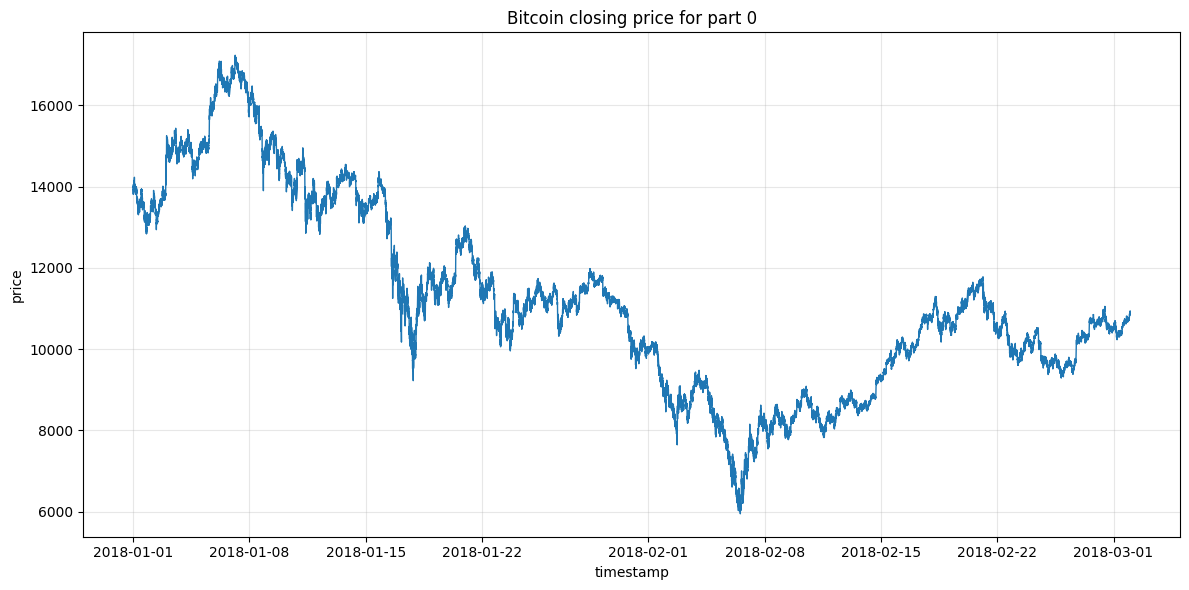

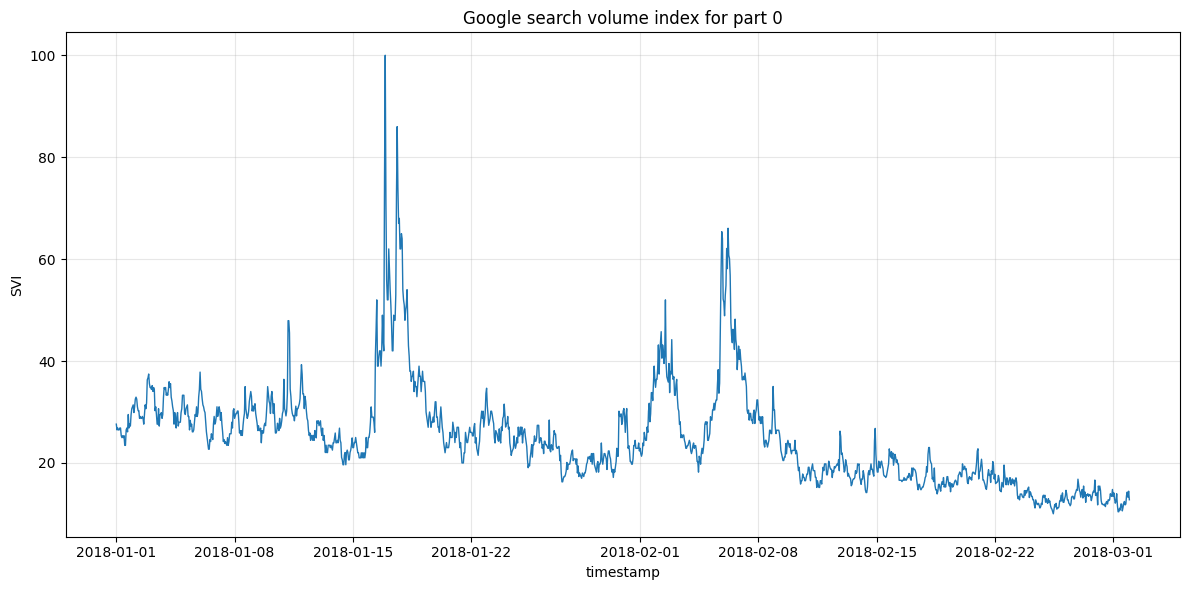

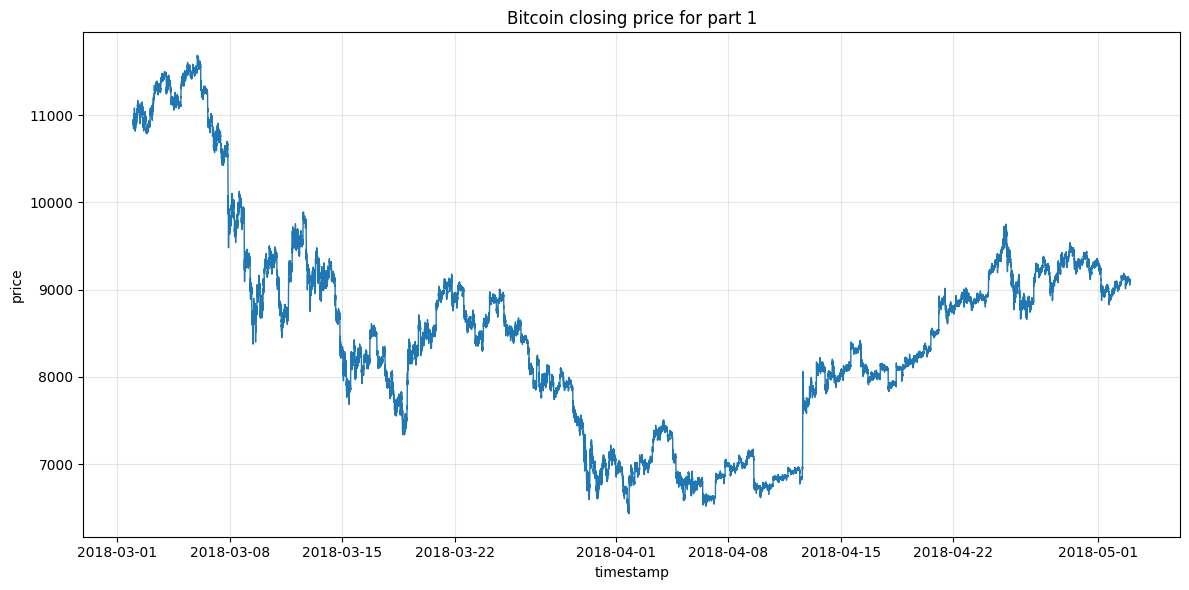

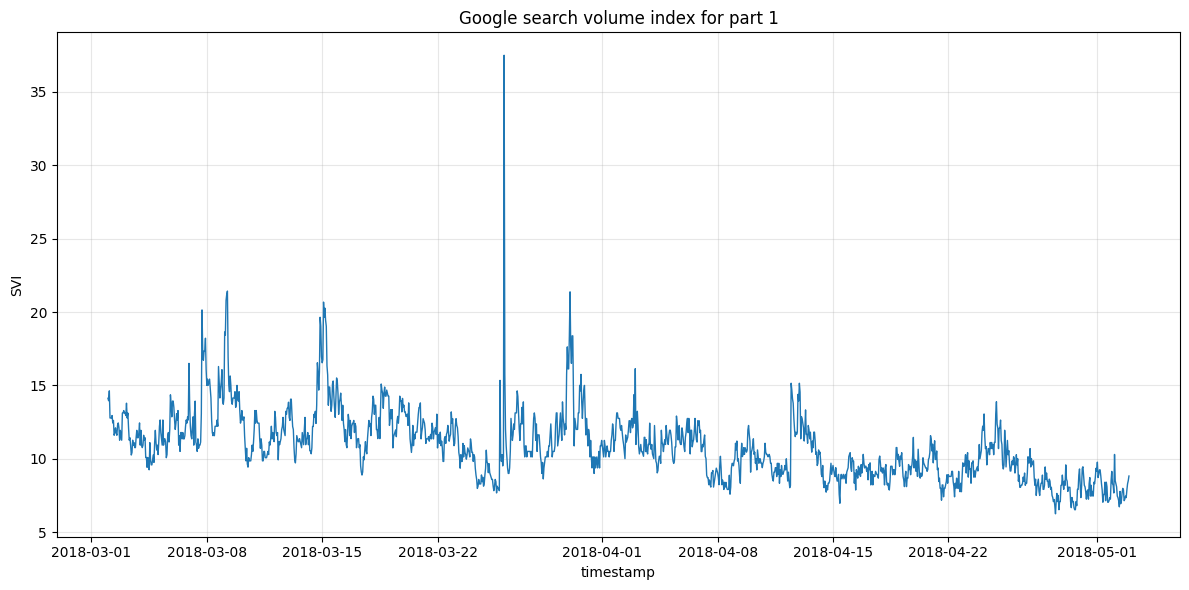

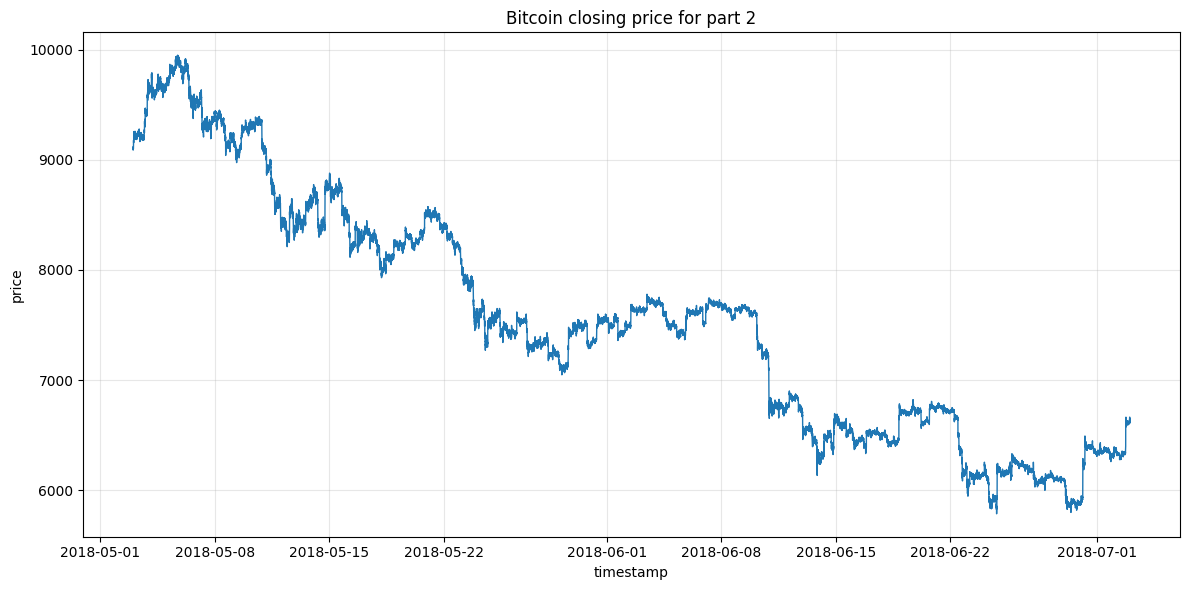

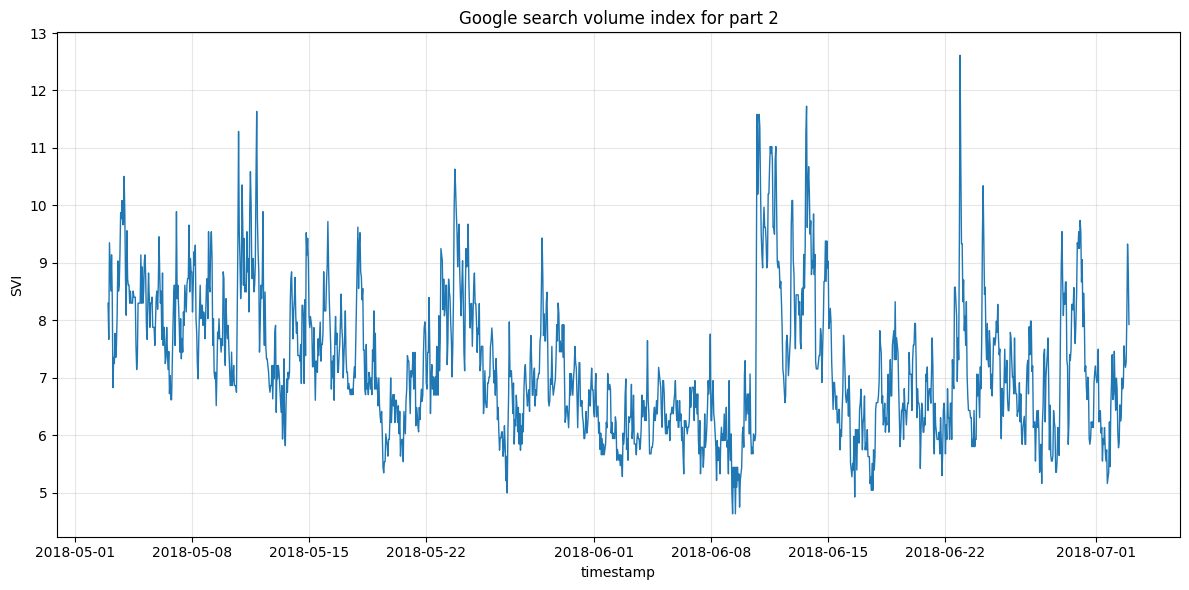

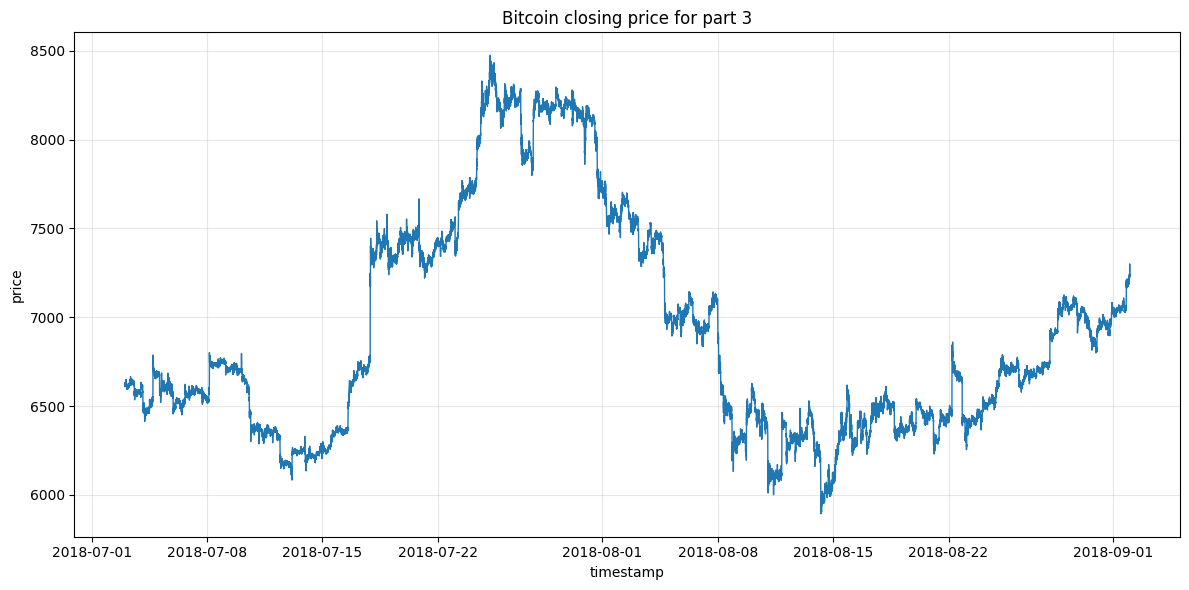

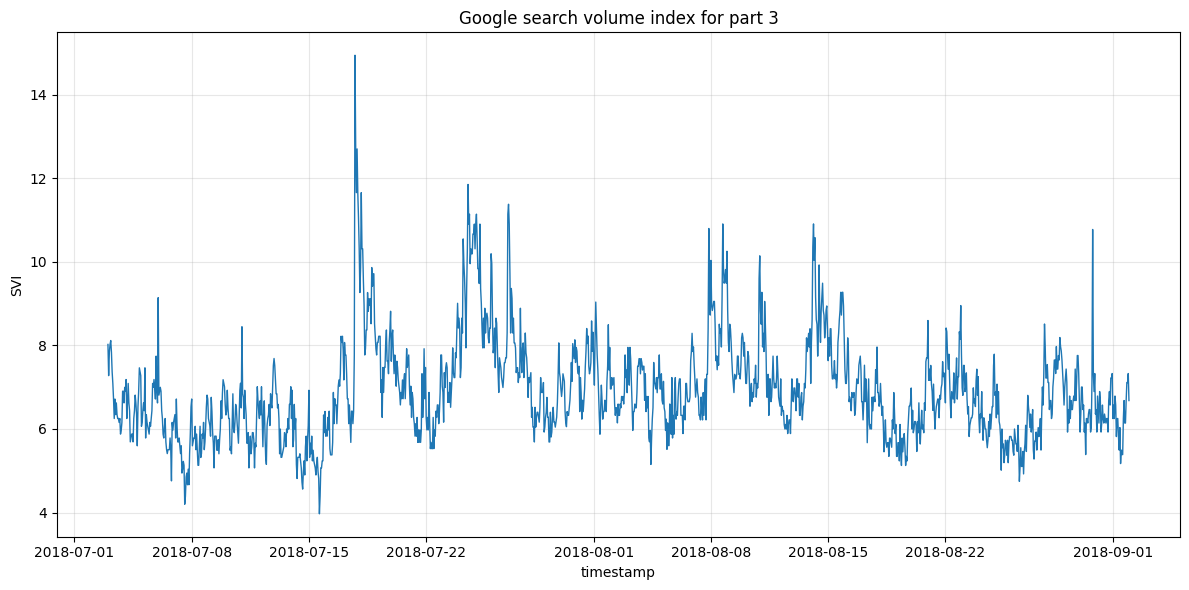

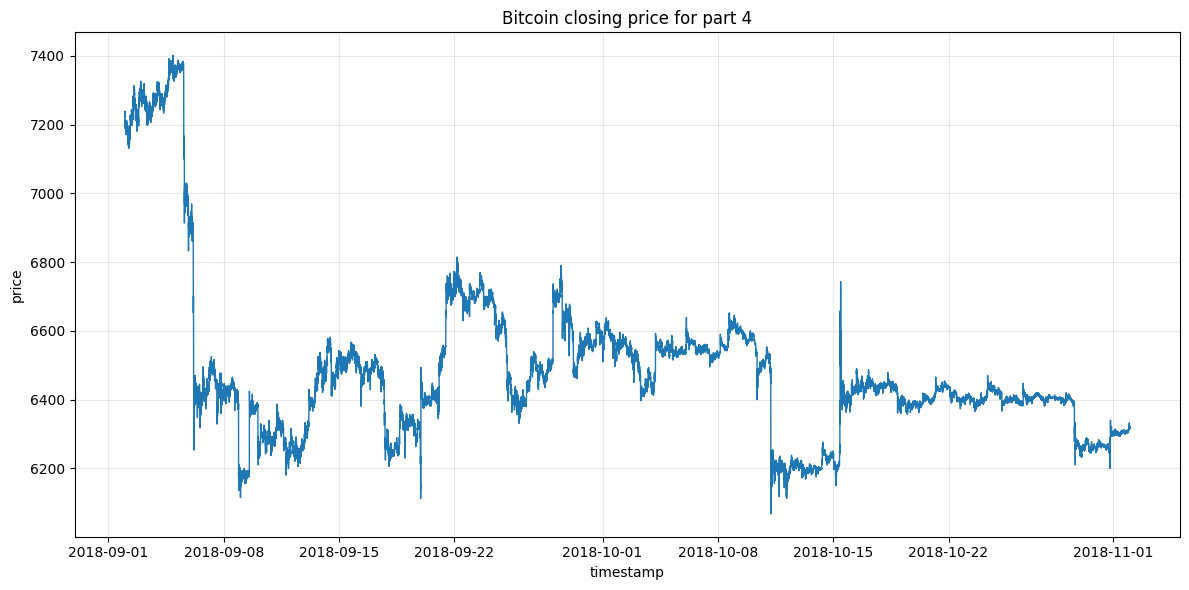

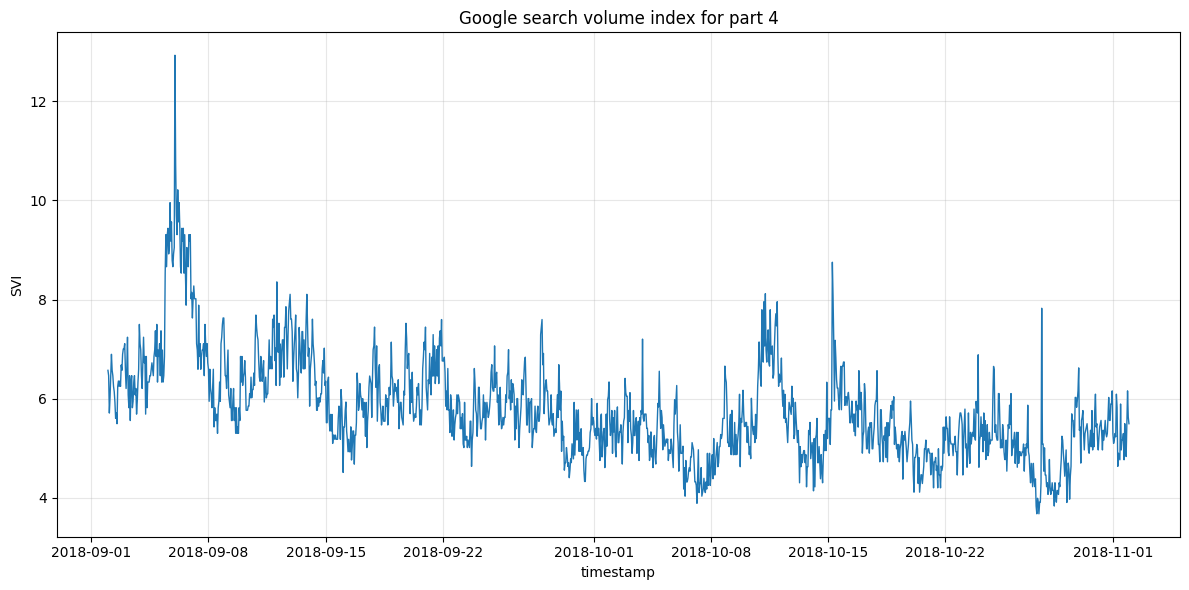

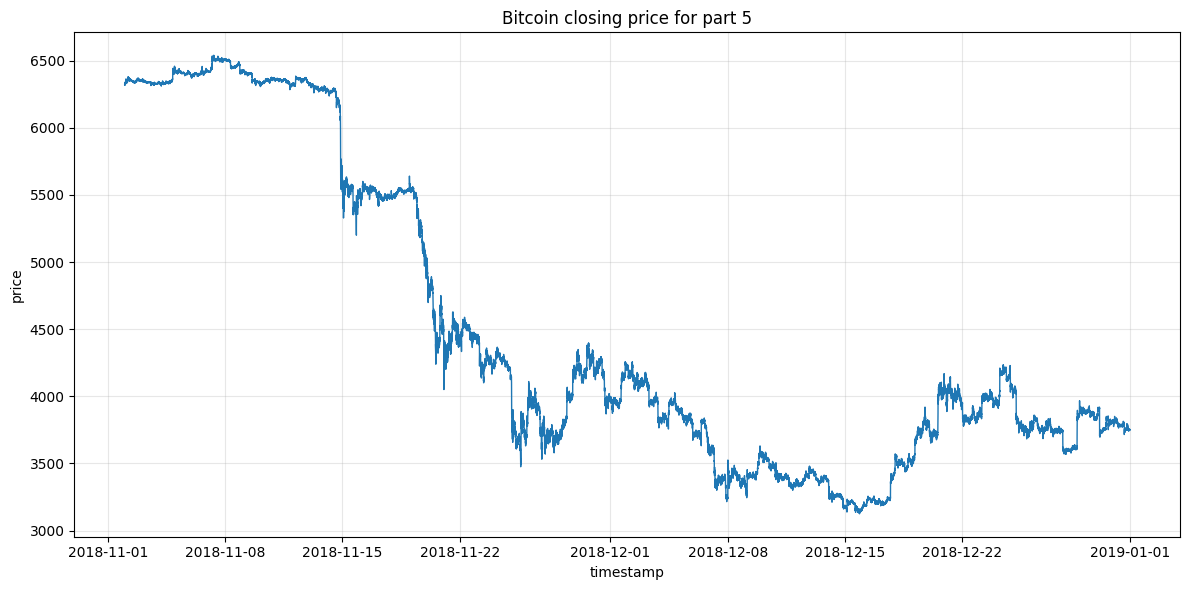

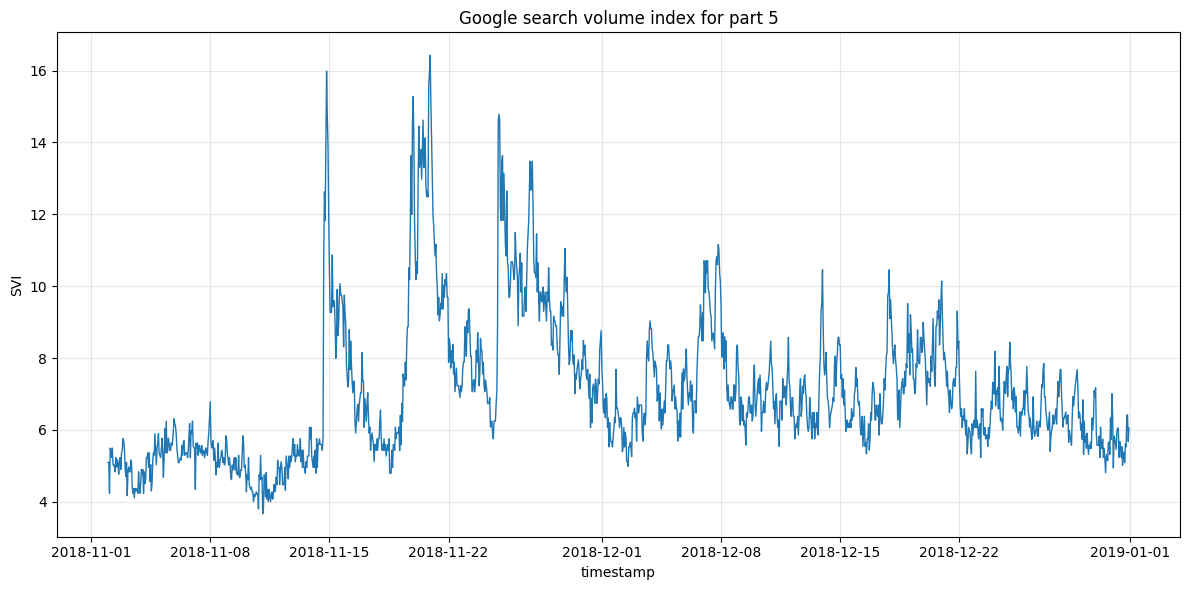

In [6]:
for i, (start, end) in enumerate(ranges):
    dfb = slice_data(df_btc_2018, start, end, ["timestamp", "price"])
    plot_data(dfb, "timestamp", "price", f"Bitcoin closing price for part {i}")
    
    dfs = slice_data(df_search_2018, start, end, ["timestamp", "SVI"])
    plot_data(dfs, "timestamp", "SVI", f"Google search volume index for part {i}")


### Preparing part 0, 1, 2 and 3

In the following sections, we examine the relationship between the Google Search Volume Index (SVI), as well as its first difference, and the volatility and momentum of the Bitcoin price. Before conducting this analysis, it is necessary to assess the statistical properties of the data. Specifically, we test whether the variables are stationary and whether they follow a normal distribution, as these properties are important for the validity of the empirical methods used.


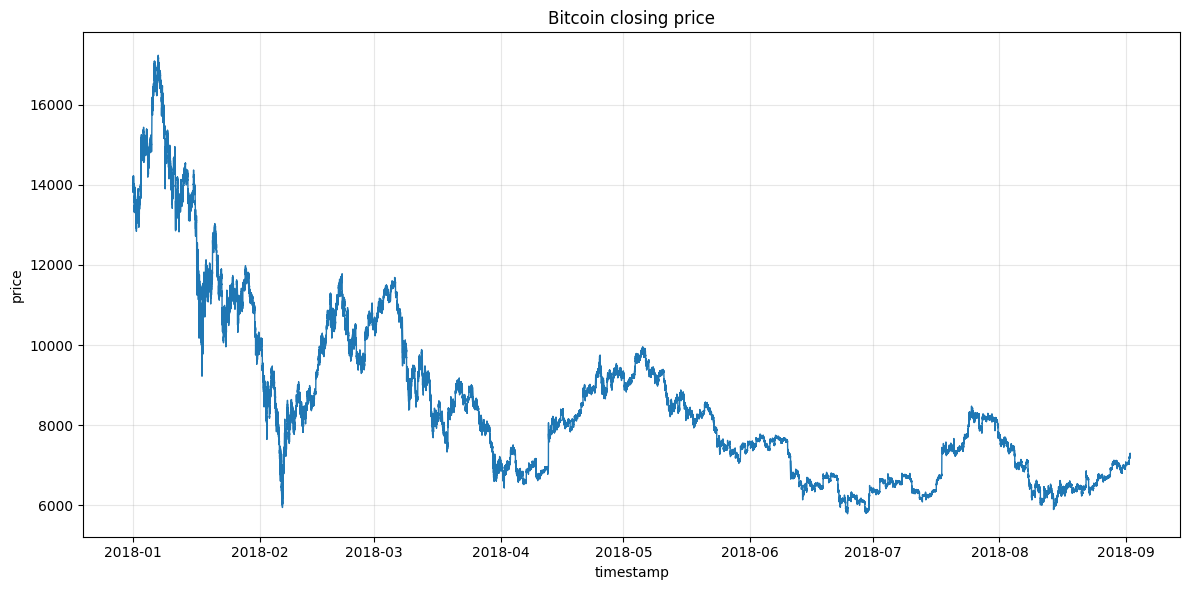

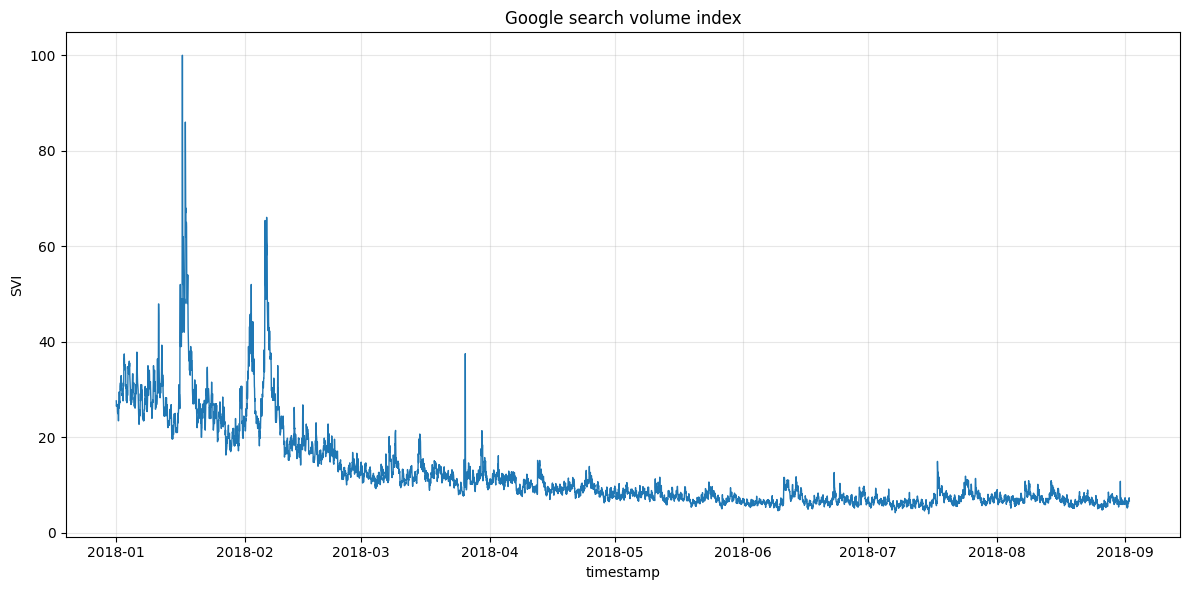

In [7]:
df_btc = slice_data(df_btc_2018, range03[0], range03[1], ["timestamp", "price"])
df_search = slice_data(df_search_2018, range03[0], range03[1], ["timestamp", "SVI"])

plot_data(df_btc, "timestamp", "price", f"Bitcoin closing price")
plot_data(df_search, "timestamp", "SVI", f"Google search volume index")


In [8]:
# Adfuller test, returns the p-value if r=True.
# If the p-value is below 0.05 the data is stationary
def ADF(df: pl.DataFrame, x: str, r=False):
    result = adfuller(df[x].drop_nulls())
    
    stat = "not stationary"
    if result[1] < 0.05:
        stat = "stationary"

    print(f"The data for {x} is {stat} (p-value = {result[1]:.3e})")

    if r:
        return p_value


# Normality, returns the p-value if r=True.
# If the p-value is below 0.05 the data has normal distribution
def norm_test(df: pl.DataFrame, x: str, r=False):
    data = np.array(df[x].drop_nulls())
    data_std = (data - np.mean(data)) / np.std(data)

    stat, p_value = kstest(data_std, 'norm')
    
    norm = "does not have normal distribution"
    if p_value < 0.05:
        norm = "has normal distribution"

    print(f"The data for {x} {norm} (p-value = {p_value:.3e})")
    
    if r:
        return p_value


In [9]:
ADF(df_search, "SVI")
norm_test(df_search, "SVI")


The data for SVI is stationary (p-value = 8.345e-05)
The data for SVI has normal distribution (p-value = 1.410e-240)


Now we also compute the column with SVI differences: 

$$dsvi_t = svi_t - svi_{t-1}$$

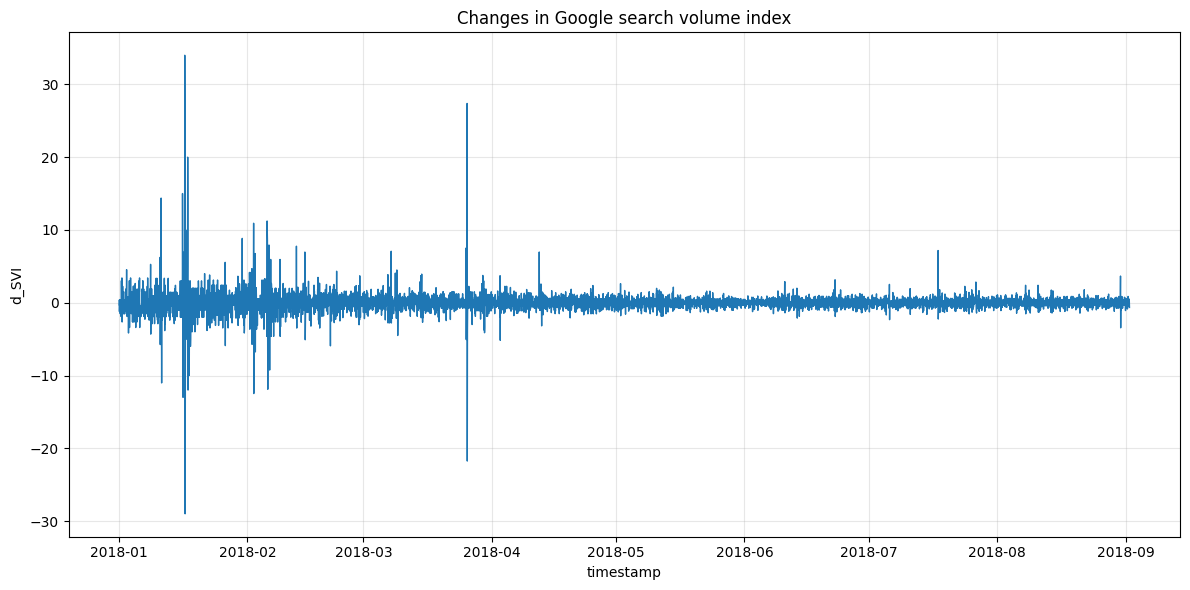

In [10]:
# adding column with differences
df_search = df_search.with_columns([
        (pl.col("SVI") - pl.col("SVI").shift(1)).alias("d_SVI")
    ])

plot_data(df_search, "timestamp", "d_SVI", f"Changes in Google search volume index")


In [11]:
ADF(df_search, "d_SVI")
norm_test(df_search, "d_SVI")


The data for d_SVI is stationary (p-value = 9.181e-22)
The data for d_SVI has normal distribution (p-value = 6.687e-141)


### Preparing data for part 4

The data from period 4 is reserved for model validation and is used to evaluate the predictive performance of any models developed.

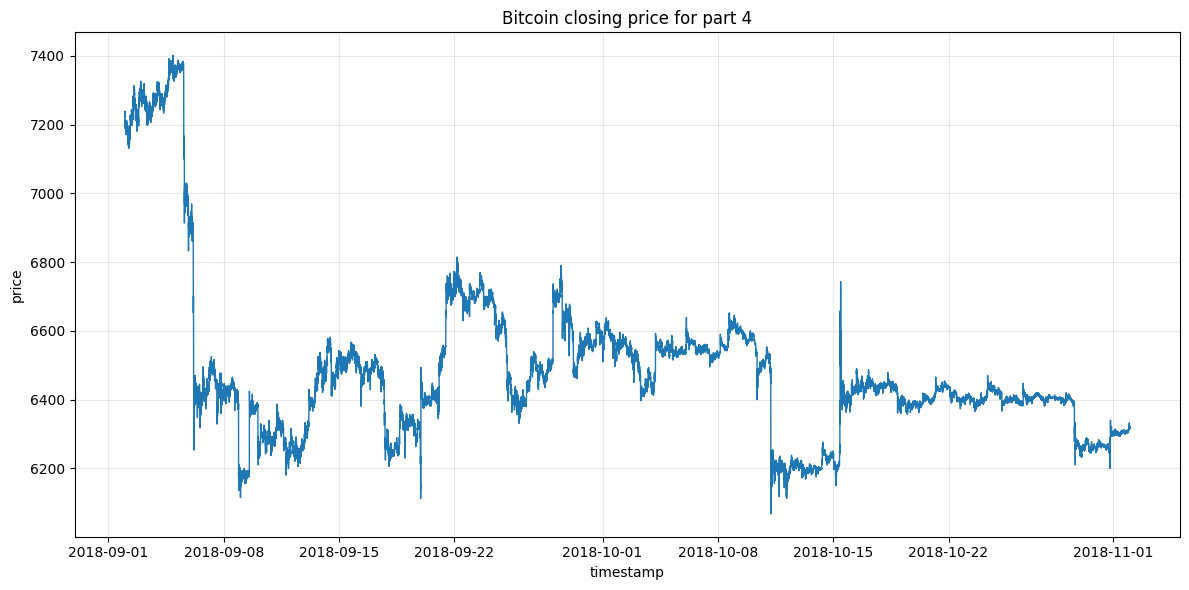

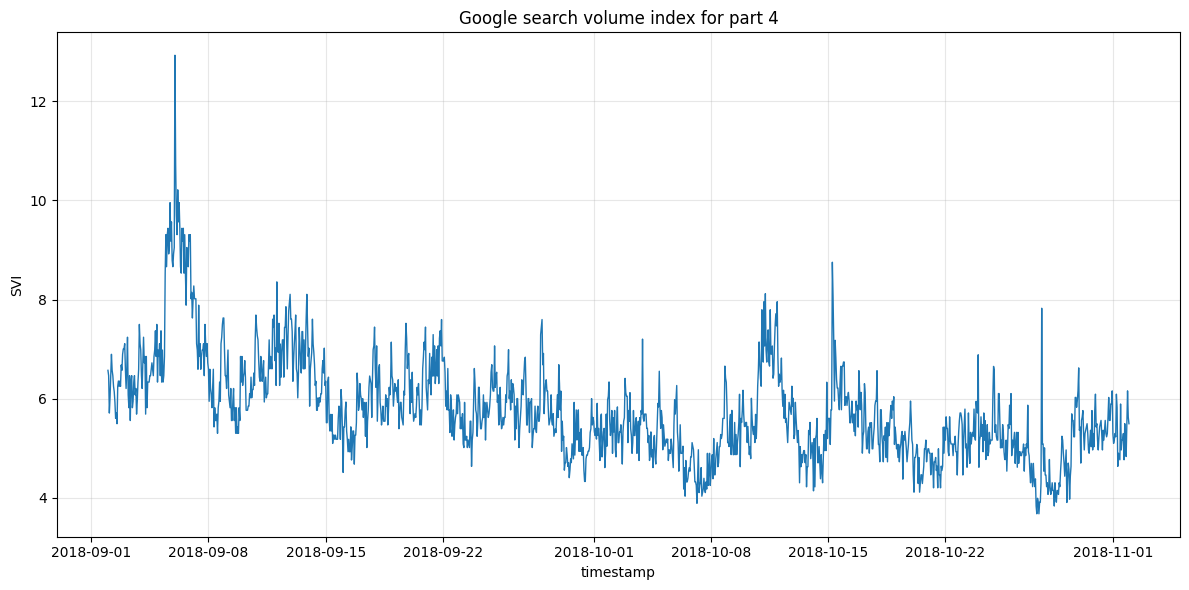

In [12]:
df_btc_4 = slice_data(df_btc_2018, range4[0], range4[1], ["timestamp", "price"])
df_search_4 = slice_data(df_search_2018, range4[0], range4[1], ["timestamp", "SVI"])

plot_data(df_btc_4, "timestamp", "price", f"Bitcoin closing price for part 4")
plot_data(df_search_4, "timestamp", "SVI", f"Google search volume index for part 4")

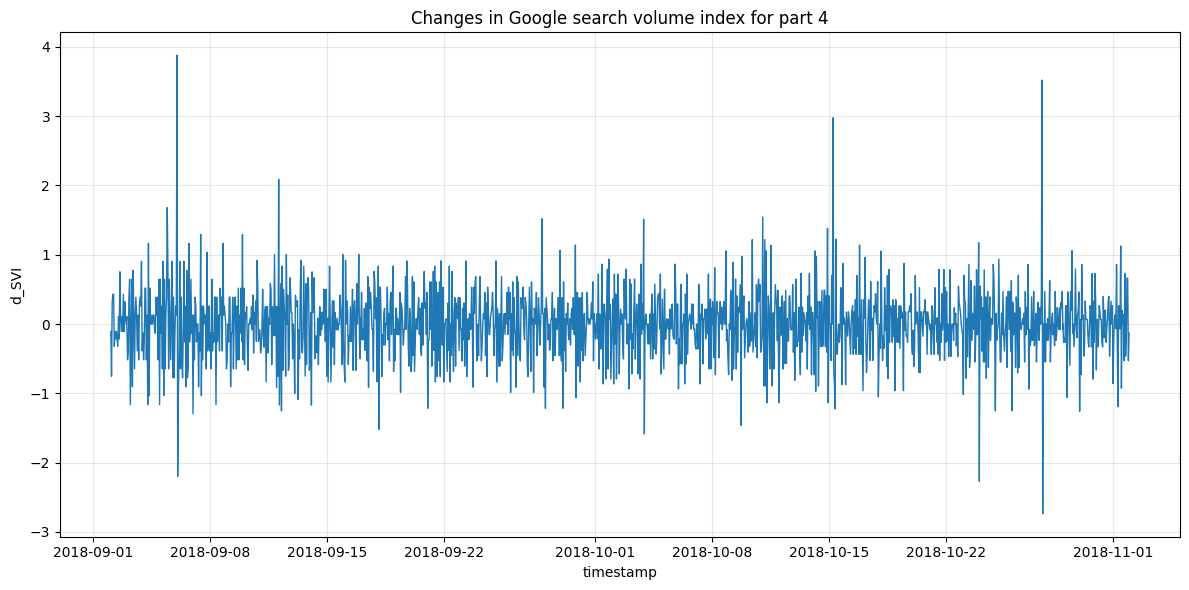

In [13]:
# adding column with differences
df_search_4 = df_search_4.with_columns([
        (pl.col("SVI") - pl.col("SVI").shift(1)).alias("d_SVI")
    ])

plot_data(df_search_4, "timestamp", "d_SVI", f"Changes in Google search volume index for part 4")

## Volatility

Short-term volatility is defined as the standard deviation of Bitcoin prices within a 24-hour window. In this section, the relationship between volatility and Google search volume is examined.

As a first step, we analyze the correlation between the two variables. The following hypotheses are tested:
- $H_0$: There is no correlation between x and y, that is, $\beta = 0$
- $H_1$: There exists correlation between x and y, that is, $\beta \neq 0$.

With x = {SVI, difference SVI} and y = {volatility, difference volatility}


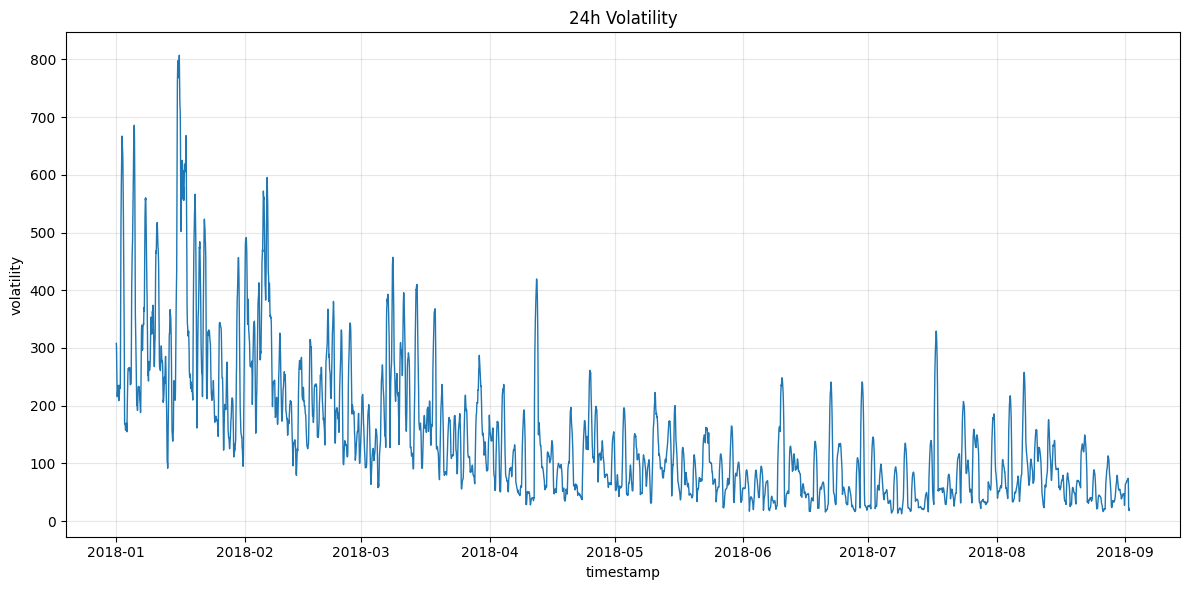

In [14]:
# making a new dataframe with volatility
df_vol = (df_btc.group_by_dynamic(
        index_column="timestamp",
        every="1h",
        period="24h"
    )
    .agg(pl.col("price").std().alias("volatility"))
    )

plot_data(df_vol, "timestamp", "volatility", f"24h Volatility")


In [15]:
ADF(df_vol, "volatility")
norm_test(df_vol, "volatility")


The data for volatility is stationary (p-value = 2.280e-05)
The data for volatility has normal distribution (p-value = 6.262e-101)


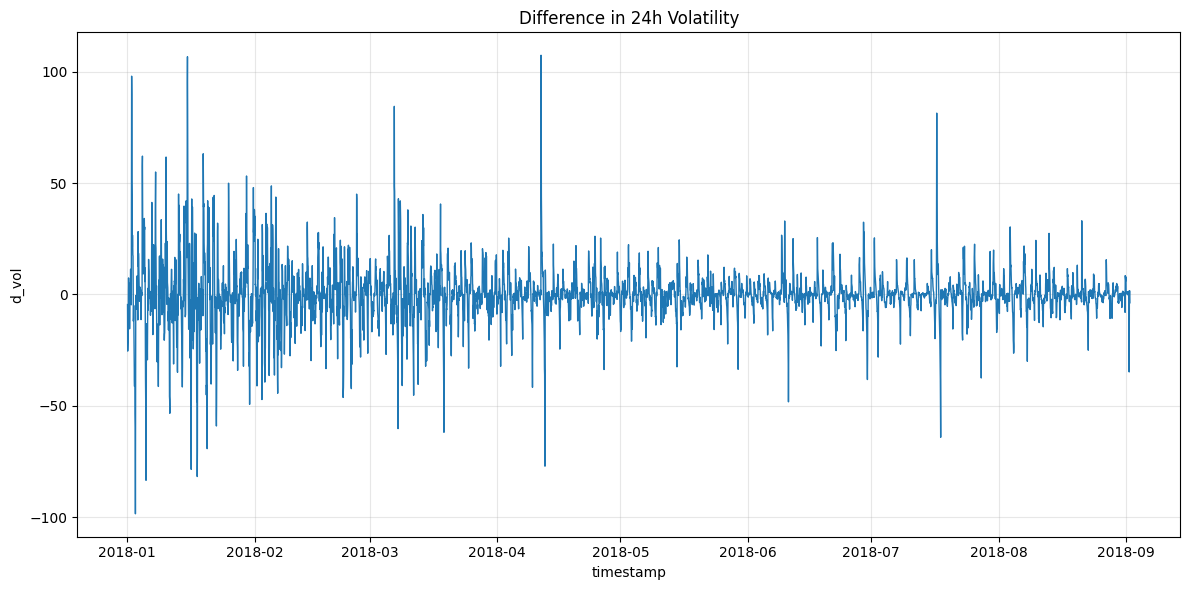

In [16]:
df_vol = df_vol.with_columns([
        (pl.col("volatility") - pl.col("volatility").shift(1)).alias("d_vol")
    ])

plot_data(df_vol, "timestamp", "d_vol", f"Difference in 24h Volatility")


In [17]:
ADF(df_vol, "d_vol")
norm_test(df_vol, "d_vol")

The data for d_vol is stationary (p-value = 2.022e-30)
The data for d_vol has normal distribution (p-value = 2.127e-97)


In [18]:
# working dataframe for this section
# combine SVI and  volatility into one dataframe
df_svi_vol = df_vol.join(
        df_search,
        on="timestamp",
        how="inner"
    )


In [19]:
# Pearson's correlation test
# retuns beta, p-value touple
# p-value = the likelihood of observing the beta if there was no correlation at all
def corr_test(df: pl.DataFrame, x: str, y: str):
    x_val = np.array(df[x].drop_nulls())
    y_val = np.array(df[y].drop_nulls())
    
    return pearsonr(x_val, y_val)


In [20]:
def corr_matrix(df: pl.DataFrame, x_list, y_list):
    corr_matrix = np.zeros((len(x_list), len(y_list)))
    p_matrix = np.zeros((len(x_list), len(y_list)))
    
    for i, x in enumerate(x_list):
        for j, y in enumerate(y_list):
            df_temp = df.select([x, y]).drop_nulls()
            r, p = corr_test(df_temp, x, y)
            corr_matrix[i, j] = r
            p_matrix[i, j] = p
    
    annot = np.array([[f"{corr_matrix[i,j]:.2f}\n(p={p_matrix[i,j]:.3f})" 
                       for j in range(len(y_list))] for i in range(len(x_list))])
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_matrix, annot=annot, fmt='', cmap="coolwarm", center=0, linewidths=0.5,
                xticklabels=y_list, yticklabels=x_list)
    plt.title("Correlation Matrix with p-values")
    plt.show()


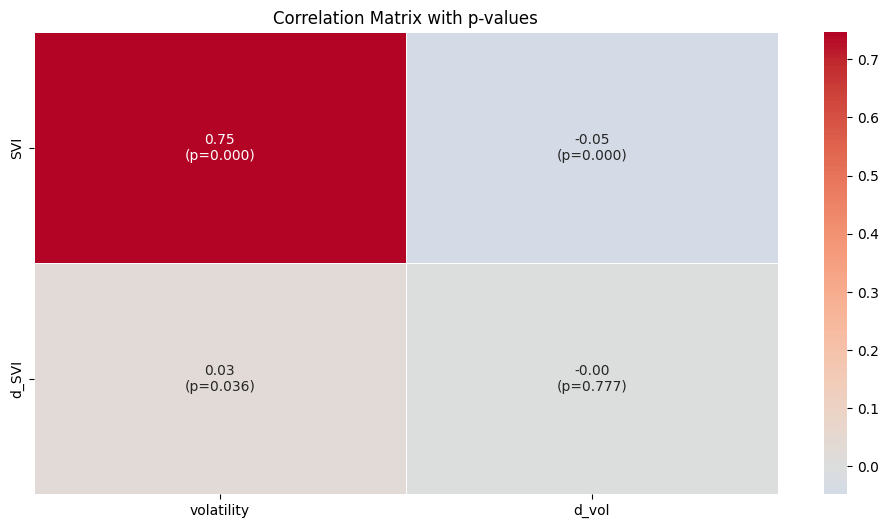

In [21]:
corr_matrix(df_svi_vol, ["SVI", "d_SVI"], ["volatility", "d_vol"])


In [22]:
# scatter plot with two variables
def plot_scatter(df: pl.DataFrame, x: str, y: str, title: str):
    plt.figure(figsize=(12, 6))
    plt.scatter(df[x], df[y], s=5)
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


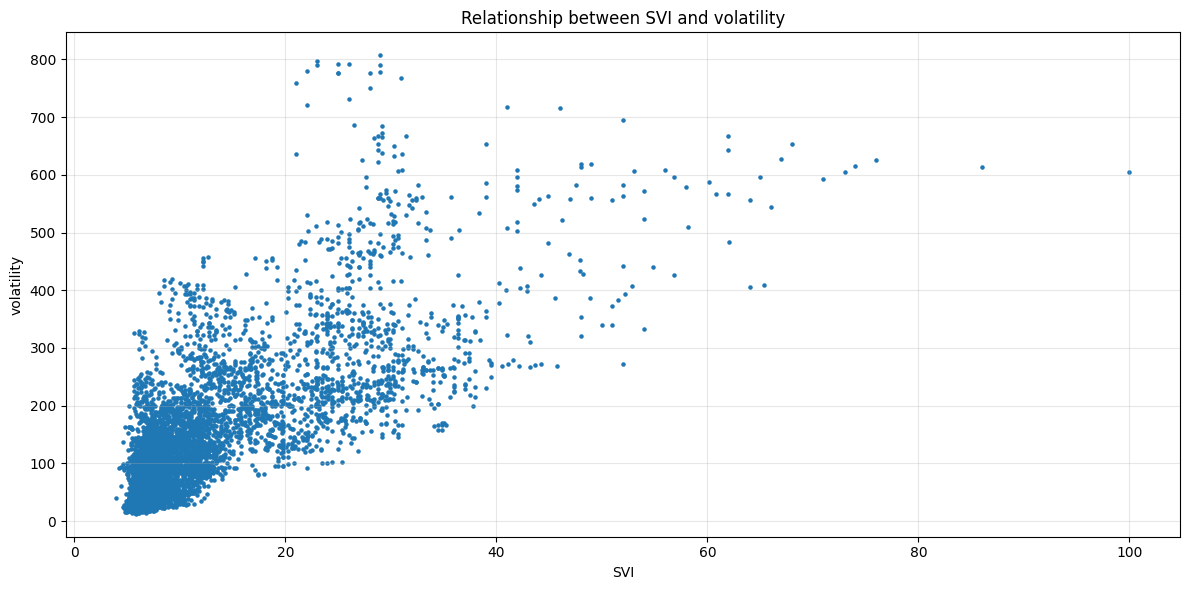

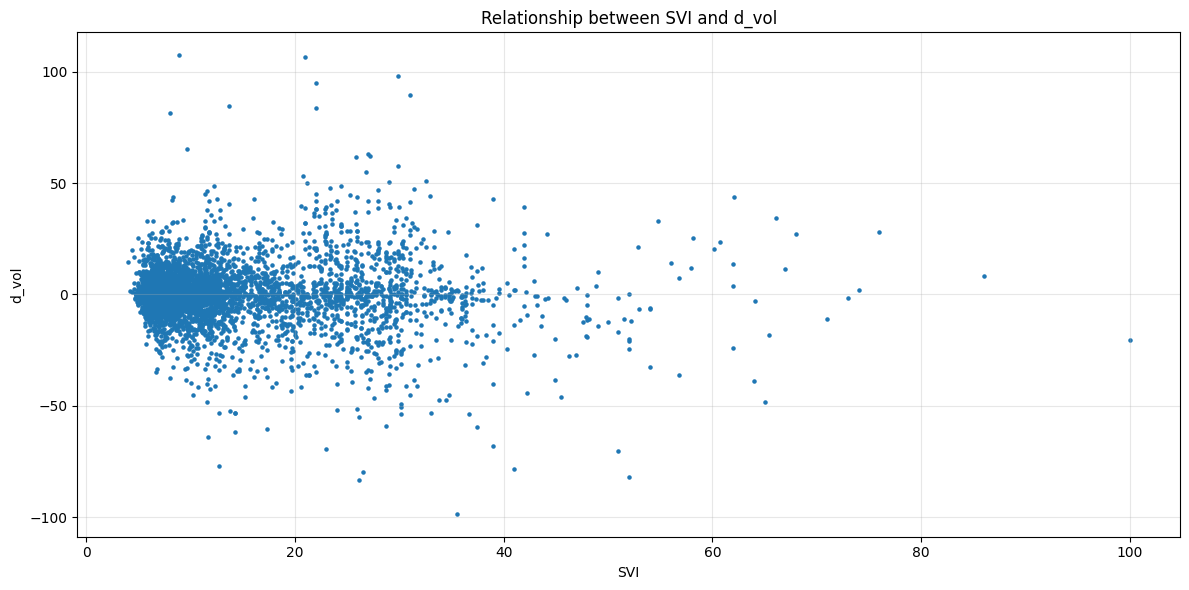

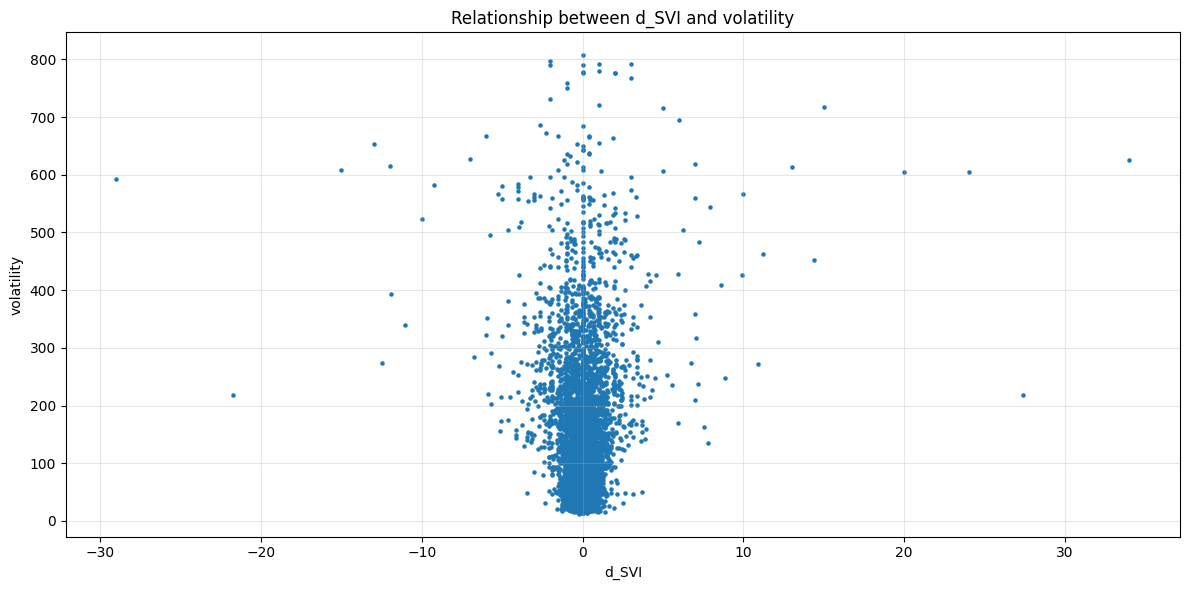

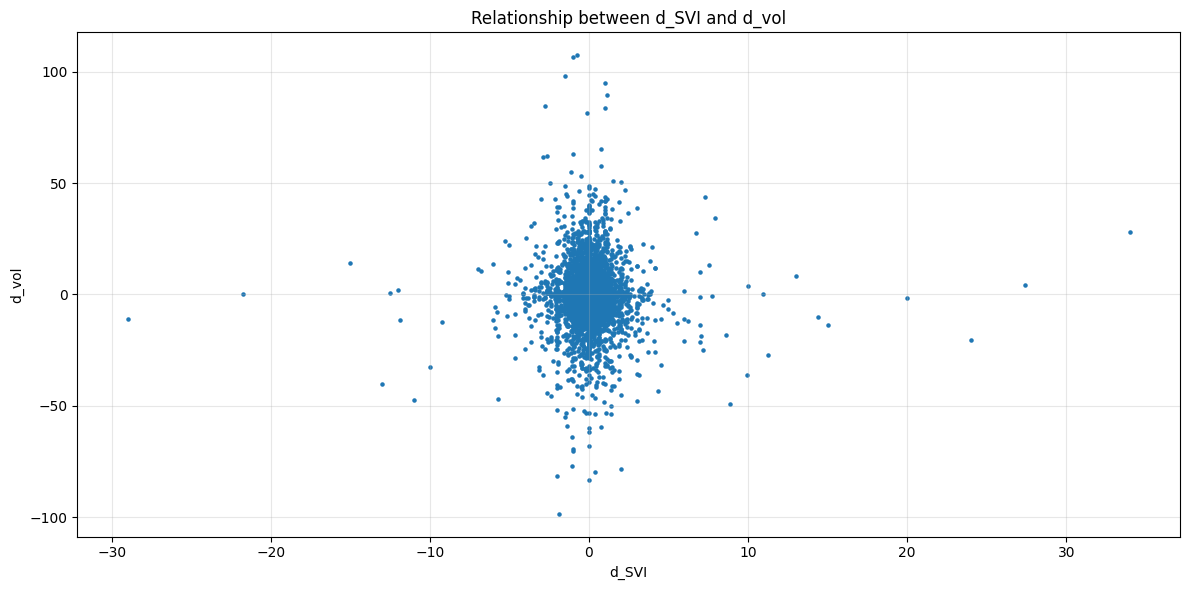

In [23]:
for x in ["SVI", "d_SVI"]:
    for y in ["volatility", "d_vol"]:
        plot_scatter(df_svi_vol, x, y, f"Relationship between {x} and {y}")


### Interpretation of the correlation results

- The Search Volume Index (SVI) shows a strong positive correlation with volatility, which is statistically significant. (reject null hypothesis)
- The Search Volume Index (SVI) shows a weak negative correlation with difference in volatility, which is statistically significant. (reject null hypothesis)
- The difference in Search Volume Index (d_SVI) shows a weak positive correlation with volatility, which is statistically significant. (reject null hypothesis)
- The difference in Search Volume Index (d_SVI) shows no correlation with difference in volatility, with p-value > 0.05. (fail to reject null hypothesis)

Although (SVI, volatility), (SVI, d_vol), and (d_SVI, volatility) all show some correlation, we proceed with a linear regression model only for (SVI, volatility). This is because the other correlations are very small.

In [24]:
def lrm(df: pl.DataFrame, x: str, y: str, show_model=True):
    X = np.array(sm.add_constant(df[x]))
    Y = np.array(df[y])
    
    model = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
    if show_model:
        print(model.summary())
        
    return model.params[0], model.params[1]

In [25]:
c_vol, b_vol = lrm(df_svi_vol, "SVI", "volatility")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     498.1
Date:                Mon, 15 Dec 2025   Prob (F-statistic):          5.44e-106
Time:                        02:52:42   Log-Likelihood:                -34191.
No. Observations:                5890   AIC:                         6.839e+04
Df Residuals:                    5888   BIC:                         6.840e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.5188      4.860      4.016      0.0

In [26]:
# scatter plot with two variables and a line
def plot_scatter_lrm(df: pl.DataFrame, x: str, y: str, title: str, c, b):
    plt.figure(figsize=(12, 6))
    plt.scatter(df[x], df[y], s=5)
    
    x_lrm = df[x]
    y_lrm = c + b * x_lrm
    plt.plot(x_lrm, y_lrm, color='red', lw=1, ls="--", label="LRM")
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()

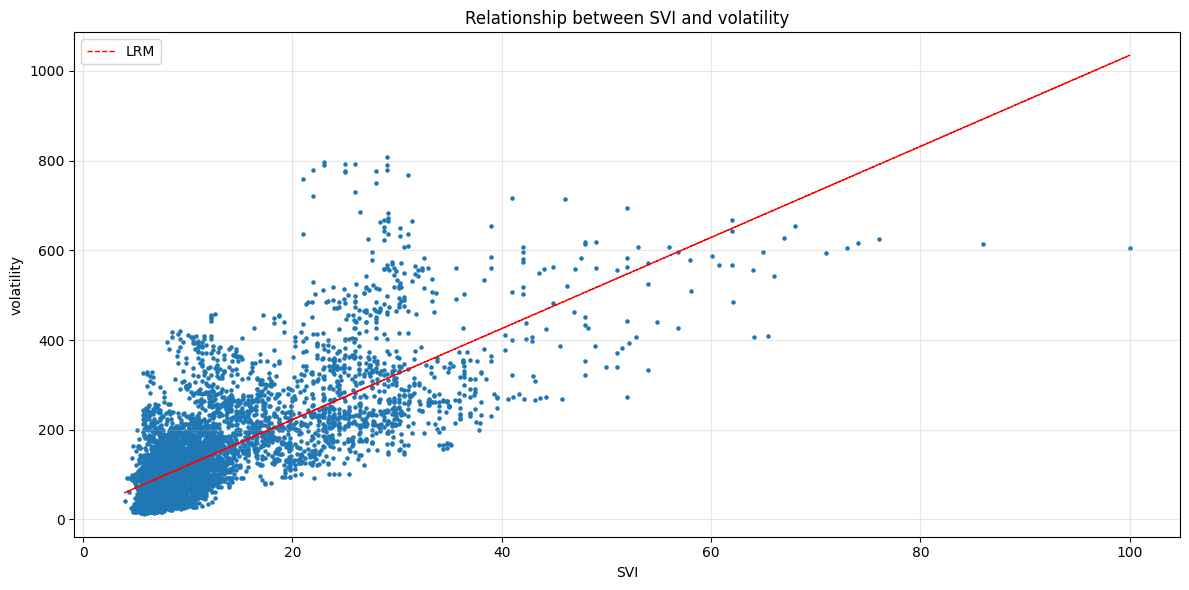

In [27]:
plot_scatter_lrm(df_svi_vol, "SVI", "volatility", "Relationship between SVI and volatility",
                 c_vol, b_vol)

### Interpretation of OLS model results

The OLS model explains approximately 56% of the variation in the dependent variable (R² ≈ 0.56), with the predictor x1 showing a significant positive effect (coefficient ≈ 10.15, p < 0.05). The intercept is 19.52 and is also statistically significant (p < 0.05). However, the residuals exhibit strong positive autocorrelation (Durbin-Watson ≈ 0.058). Still we look to test the predictive properties of the model.

### Validating the LRM for SVI x volatility


In [28]:
# actual volatility for part 4
df_vol_4 = (df_btc_4.group_by_dynamic(
        index_column="timestamp",
        every="1h",
        period="24h"
    )
    .agg(pl.col("price").std().alias("volatility"))
    )

In [29]:
# predicted volatility for part 4
df_pred_vol_4 = (df_search_4.with_columns(
    pred_vol = c_vol + b_vol * pl.col("SVI"))
    .select(["timestamp", "pred_vol"]))


In [30]:
# plot data (two functions)
def plot_data_2(df1: pl.DataFrame, x1: str, y1: str, l1: str, 
                df2: pl.DataFrame, x2: str, y2: str, l2:str, title: str):
    
    plt.figure(figsize=(12, 6))
    plt.plot(df1[x1], df1[y1], lw=1, label=l1)
    plt.plot(df2[x2], df2[y2], lw=1, label=l2)
    
    plt.title(title)
    plt.xlabel(f"{x1}")
    plt.ylabel(f"{y1}")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()


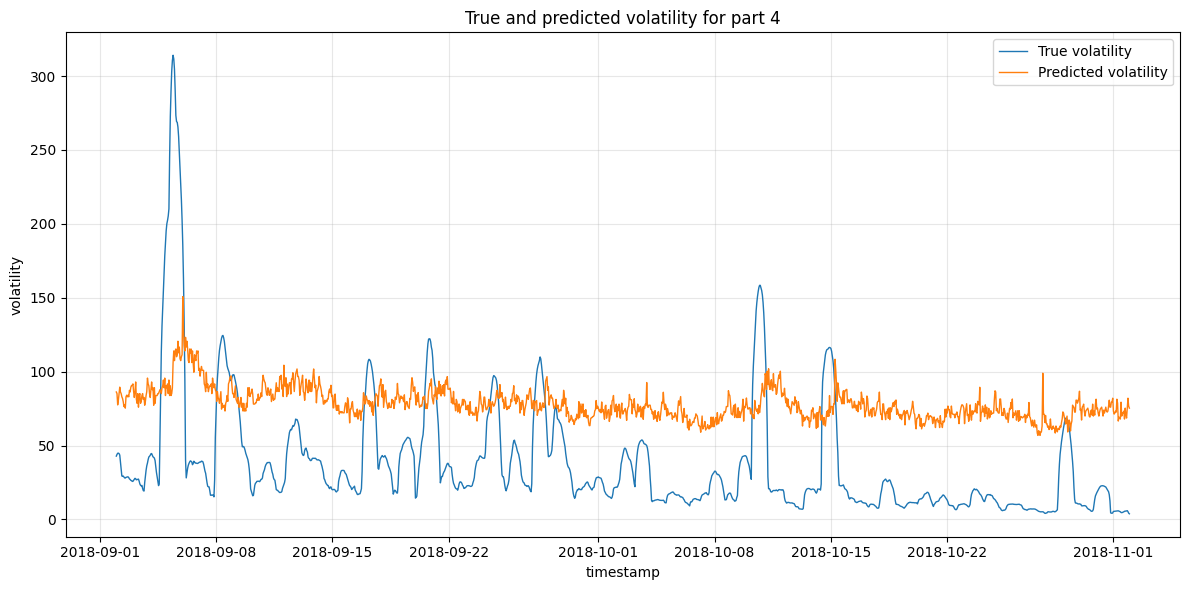

In [31]:
plot_data_2(df_vol_4, "timestamp", "volatility", "True volatility",
            df_pred_vol_4, "timestamp", "pred_vol", "Predicted volatility",
            "True and predicted volatility for part 4")


#### Hypothesis testing
Although from the graph it's already visable that the prediction isn't very accurate. We want to test if there is any predictive power at all. To test that we compare the error of the model and the benchmark. 

$L = (y_t - \hat{y}_t)^2$, $y_t$ is the true value, $\hat{y}_t$ is the predicted value.

For the benchmark random walk is used. Each step in our random walk is $\pm$ the average step for volatility in part 0 through 3.

- $H_0$: There is no predictive power $mean(L^{model}_t - L^{bench}_t) \geq 0$
- $H_1$: There is predictive power $mean(L^{model}_t - L^{bench}_t) < 0$

In [32]:
df_vol_4_loss = df_vol_4.join(
    df_pred_vol_4,
    on="timestamp",
    how="inner")

In [33]:
def loss_function(df: pl.DataFrame, x: str, y: str, z: str):
    return (df
        .with_columns(((pl.col(x) - pl.col(y)) ** 2).alias(z))
    )


In [34]:
df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "pred_vol", "loss_model")


In [35]:
def random_walk(df: pl.DataFrame, x: str, start: float, step: float):
    n = df.height

    # Generate random steps (+step or -step)
    steps = np.random.choice([-step, step], size=n)

    # Build the random walk
    walk = np.empty(n)
    walk = start + np.cumsum(steps)

    return df.with_columns(
        pl.Series(name=x, values=walk)
    )


In [36]:
# step size
step = df_vol.select(
    (pl.col("volatility") - pl.col("volatility").shift(1)).mean()
).item()

start = df_vol["volatility"][-1]  # last known volatility

df_vol_4_loss = random_walk(df_vol_4_loss, "random_walk", start, step)


In [37]:
df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "random_walk", "loss_bench")


In [38]:
# computind difference (dt) in loss
df_vol_4_loss = df_vol_4_loss.with_columns(
    d = pl.col("loss_model") - pl.col("loss_bench")
)


In [39]:
def plot_hist(data, x: str, title: str, k: int):
    plt.figure(figsize=(12, 6))
    plt.hist(data, k, density=True)
    
    # Confidence intervals
    mean = np.mean(data)
    ci_lower, ci_upper = np.percentile(data, [2.5, 97.5])

    # Plot CI and mean
    plt.axvline(mean, linestyle="--", linewidth=1, color="r", label=f"Mean: {mean:.3f}")
    plt.axvline(ci_lower, linestyle="--", linewidth=1, color="k", label=f"95% CI [{ci_lower:.2f}, {ci_upper:.2f}]")
    plt.axvline(ci_upper, linestyle="--", linewidth=1, color="k")
    
    plt.title(title)
    plt.xlabel(f"{x}")
    plt.ylabel(f"frequency")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()


In [40]:
# recieves an array that is bootstrapped
# returns an array of means
def bootstrap_means(data: np.array, N):
    rng = np.random.default_rng(seed=42)
    
    boot_means = []
    for _ in range(N):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    
    return boot_means


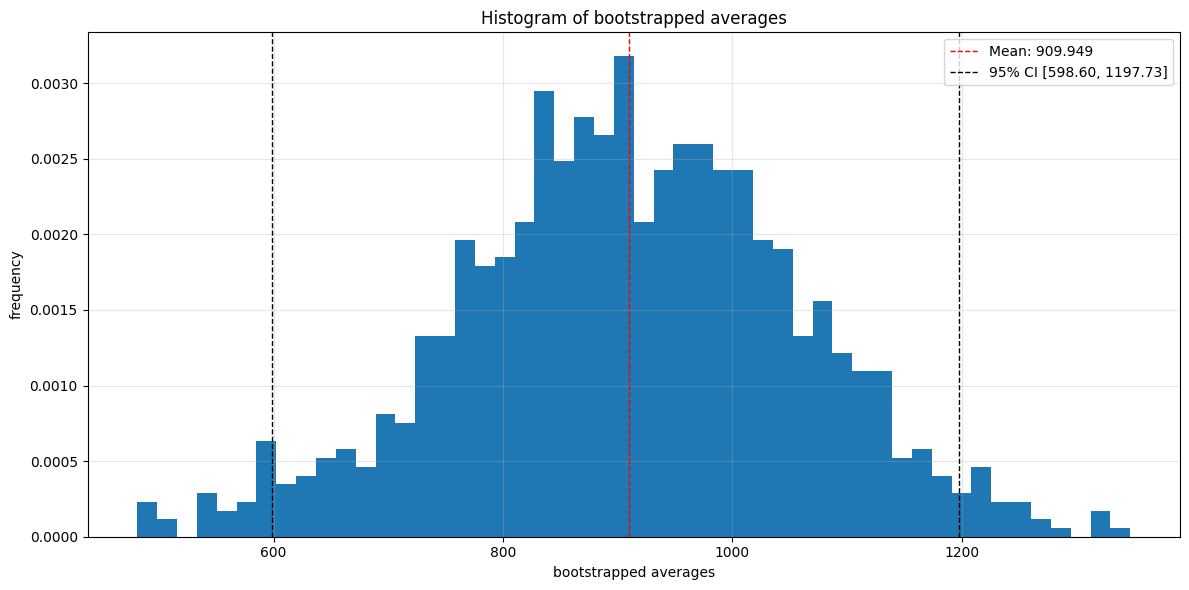

In [41]:
boot_means = bootstrap_means(np.array(df_vol_4_loss["d"]), 10**3)
plot_hist(boot_means, "bootstrapped averages", "Histogram of bootstrapped averages", 50)


The 95% confidence interval for the mean loss differential $L^{model}_t - L^{bench}_t$ lies above 0, indicating that the average is greater than 0. Therefore, we fail to reject the null hypothesis of no predictive power.

## Momentum

Momentum is defined as: $M = V_t - V_{t - x}$

In the following section the relationship between momentum and search volume index, as well as changes in search volume.


In [42]:
hours = [1, 6, 12, 24, 48]

df_btc_hourly = df_btc.filter(
    (pl.col("timestamp").dt.minute() == 0) &
    (pl.col("timestamp").dt.second() == 0)
)

df_momentum = df_btc_hourly.select(
    [
        "timestamp",
        *[
            (pl.col("price") - pl.col("price").shift(h)).alias(f"price_diff_{h}h")
            for h in hours
        ]
    ]
)


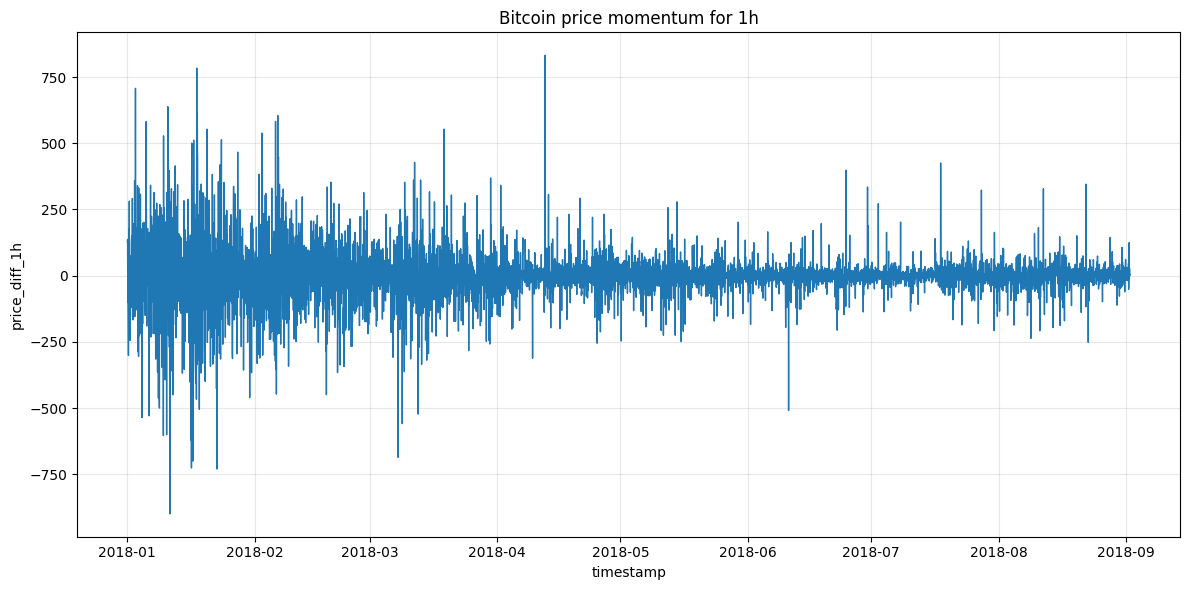

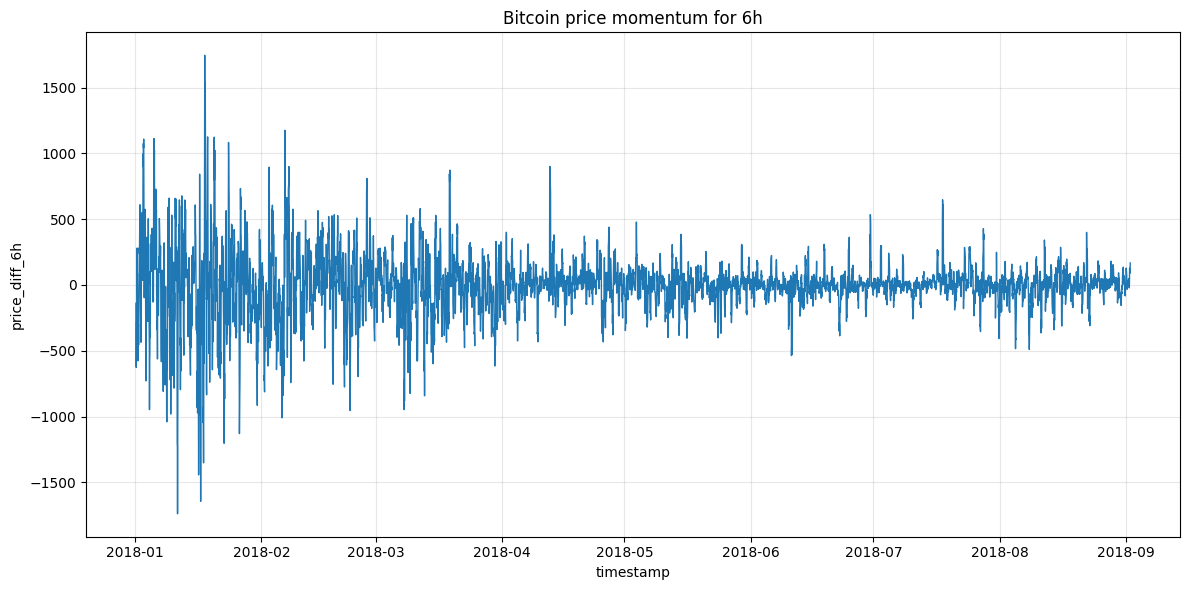

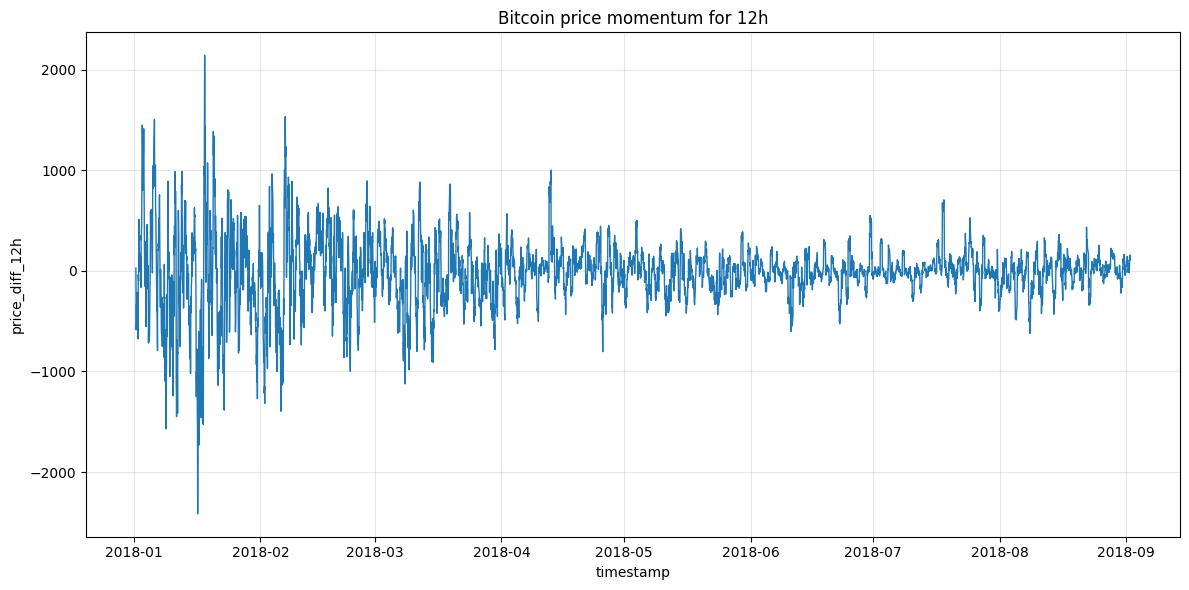

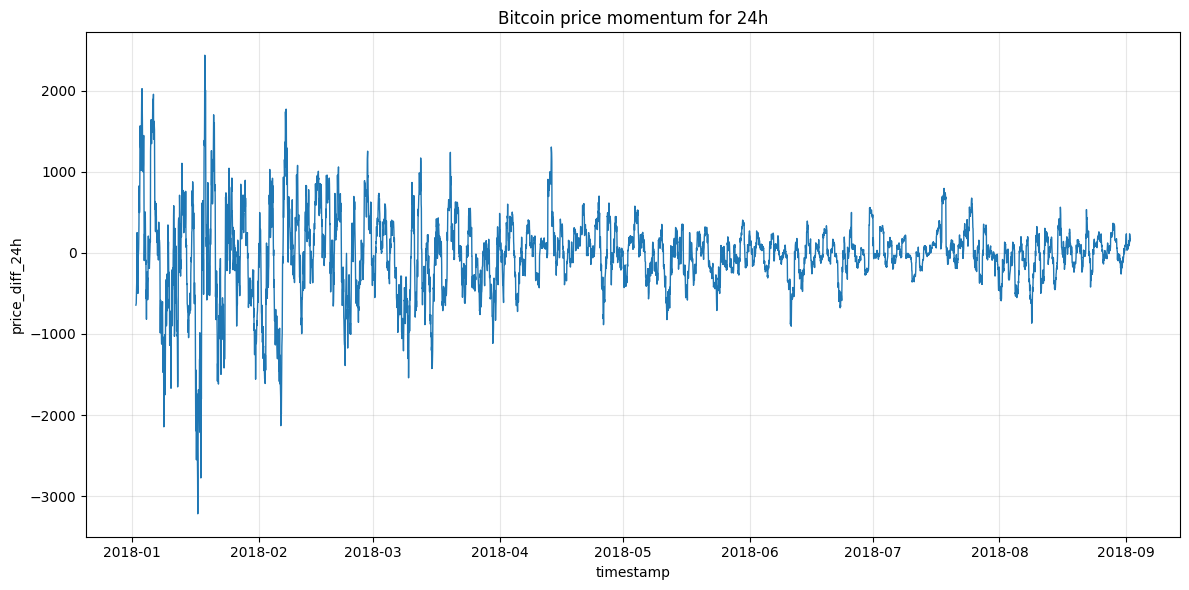

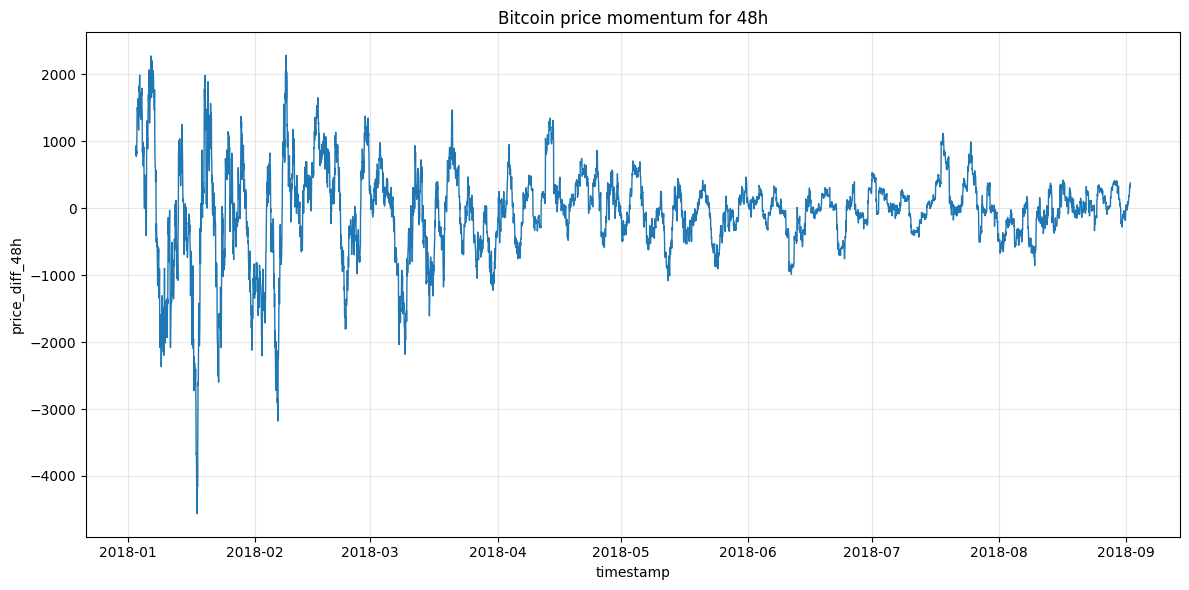

In [43]:
for h in hours:
    plot_data(df_momentum, "timestamp", f"price_diff_{h}h", f"Bitcoin price momentum for {h}h")


In [44]:
for h in hours:
    ADF(df_momentum, f"price_diff_{h}h")
    norm_test(df_momentum, f"price_diff_{h}h")
    print()


The data for price_diff_1h is stationary (p-value = 1.235e-27)
The data for price_diff_1h has normal distribution (p-value = 6.131e-110)

The data for price_diff_6h is stationary (p-value = 5.937e-24)
The data for price_diff_6h has normal distribution (p-value = 3.644e-77)

The data for price_diff_12h is stationary (p-value = 1.748e-24)
The data for price_diff_12h has normal distribution (p-value = 7.483e-50)

The data for price_diff_24h is stationary (p-value = 2.871e-15)
The data for price_diff_24h has normal distribution (p-value = 1.913e-41)

The data for price_diff_48h is stationary (p-value = 2.591e-15)
The data for price_diff_48h has normal distribution (p-value = 2.168e-43)



Again as a first step, we analyze the correlation between the two variables. The following hypotheses are tested:
- $H_0$: There is no correlation between x and y, that is, $\beta = 0$
- $H_1$: There exists correlation between x and y, that is, $\beta \neq 0$.

With x = {SVI, difference SVI} and y = {1h, 6h, 12h, 24h, 48h}

In [45]:
# combine SVI and  volatility into one dataframe
df_svi_mom = df_momentum.join(
        df_search,
        on="timestamp",
        how="inner"
    )


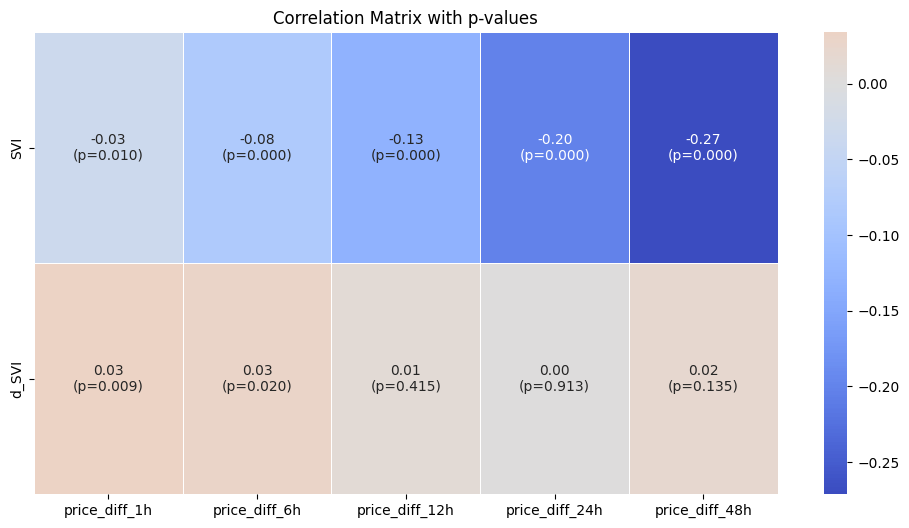

In [46]:
corr_matrix(df_svi_mom, ["SVI", "d_SVI"],
            ["price_diff_1h", "price_diff_6h",
             "price_diff_12h", "price_diff_24h",
             "price_diff_48h"])


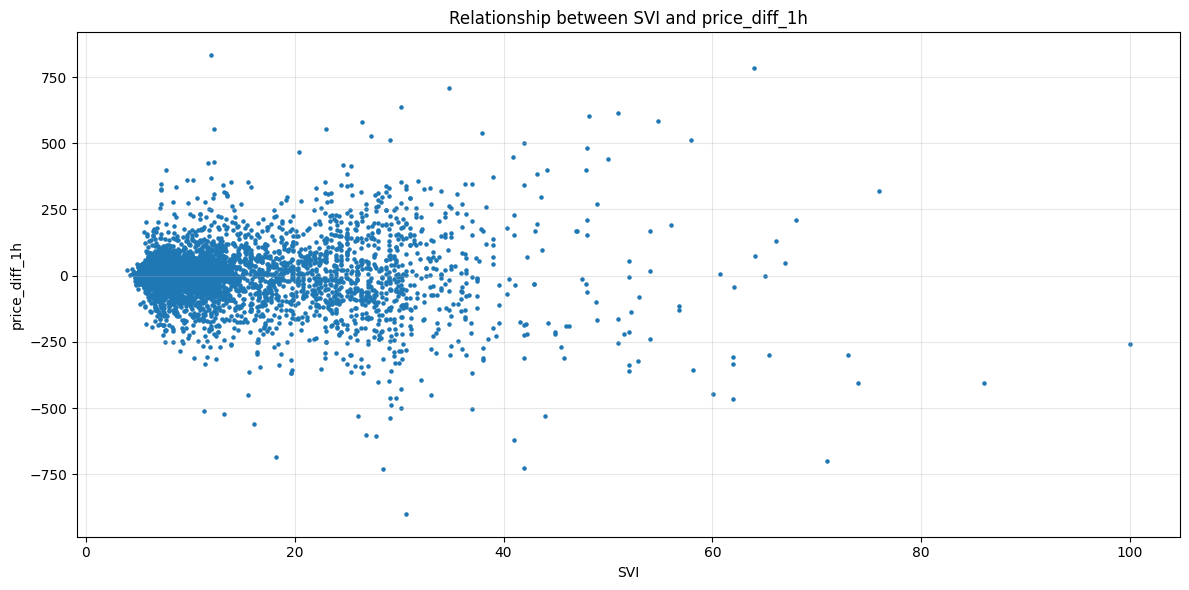

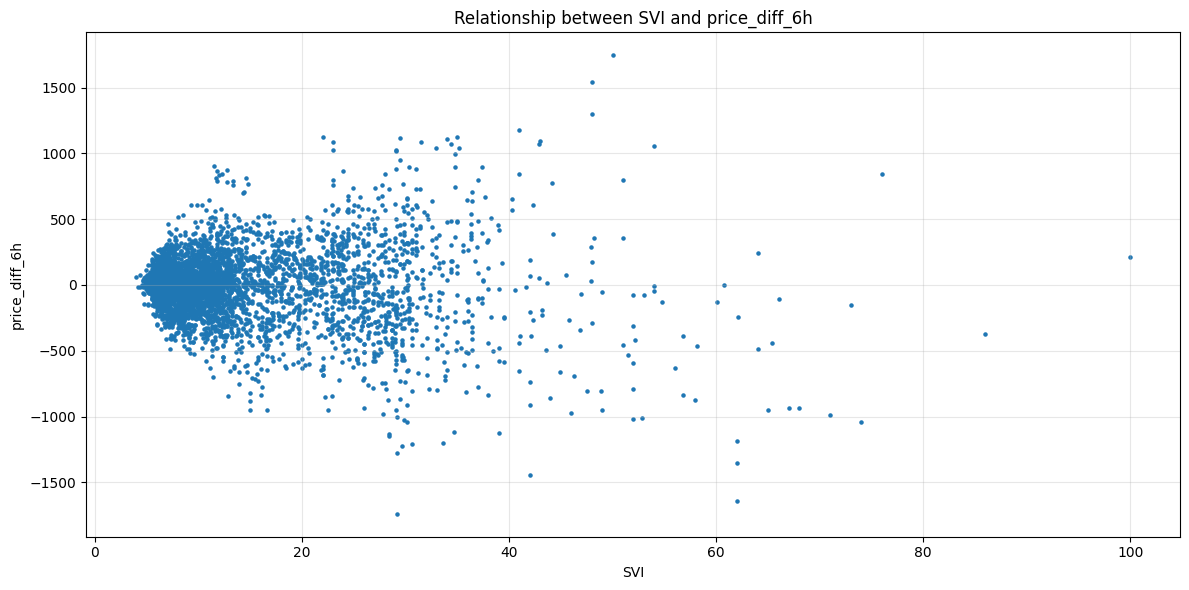

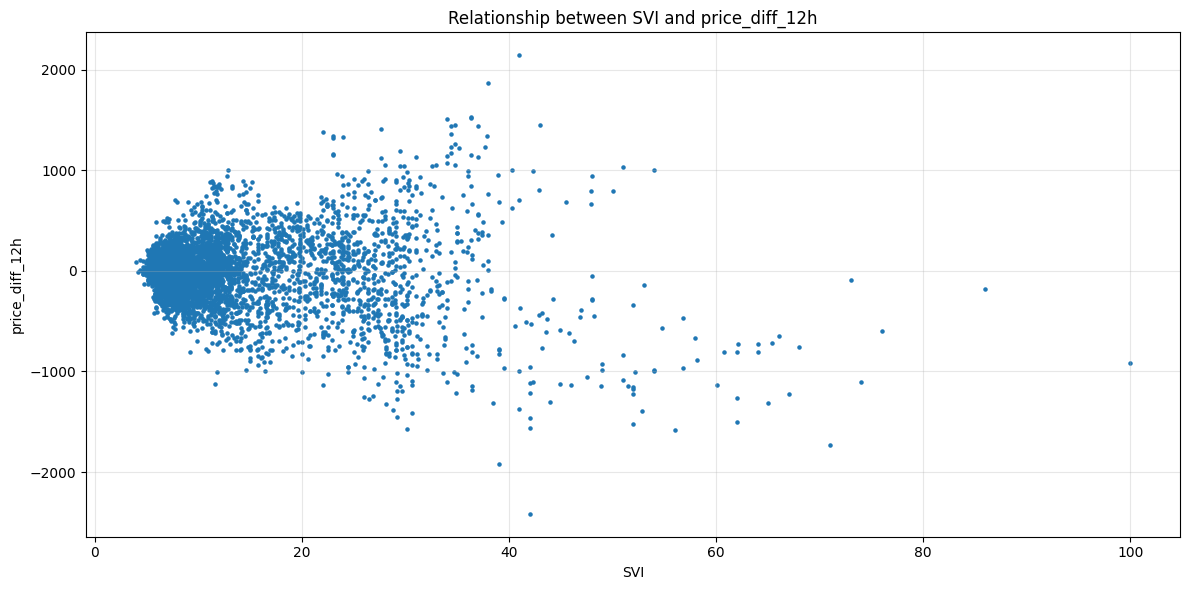

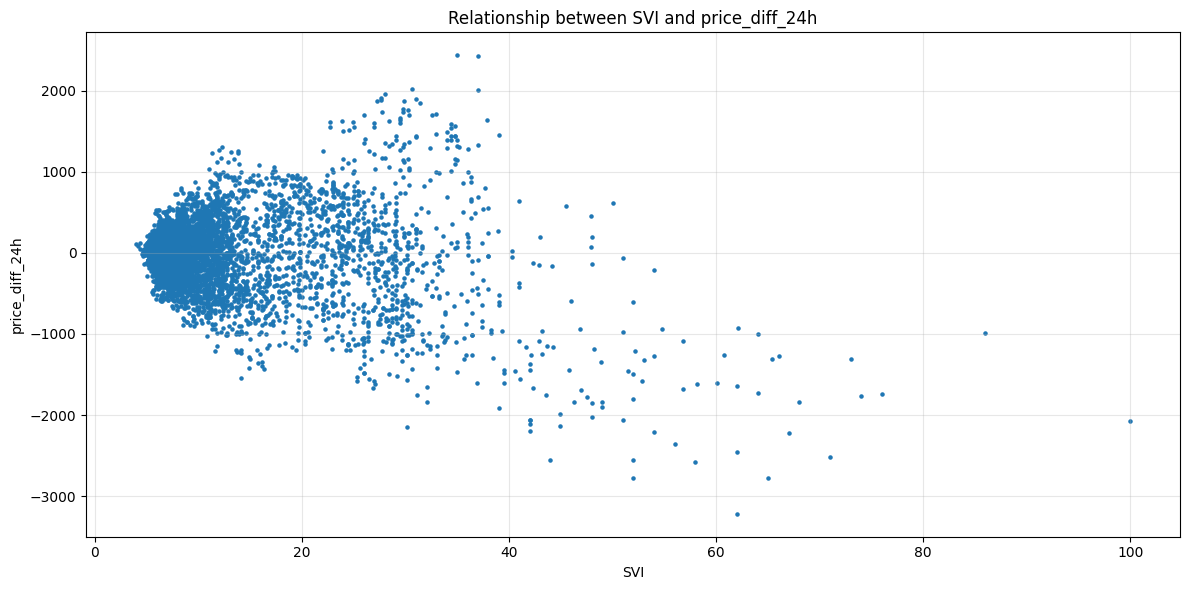

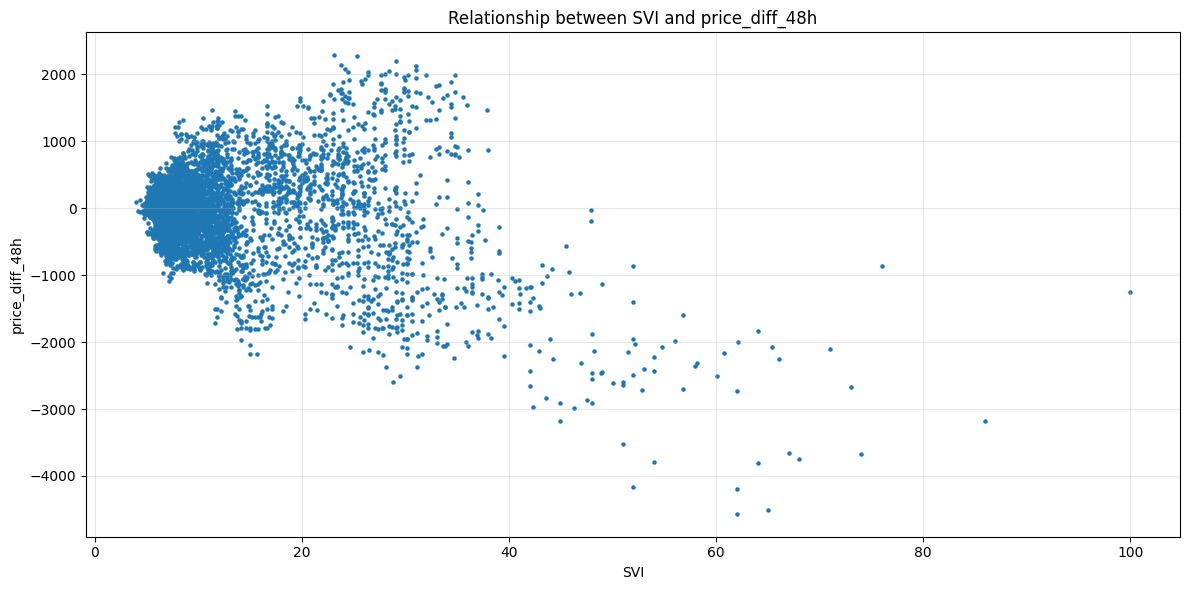

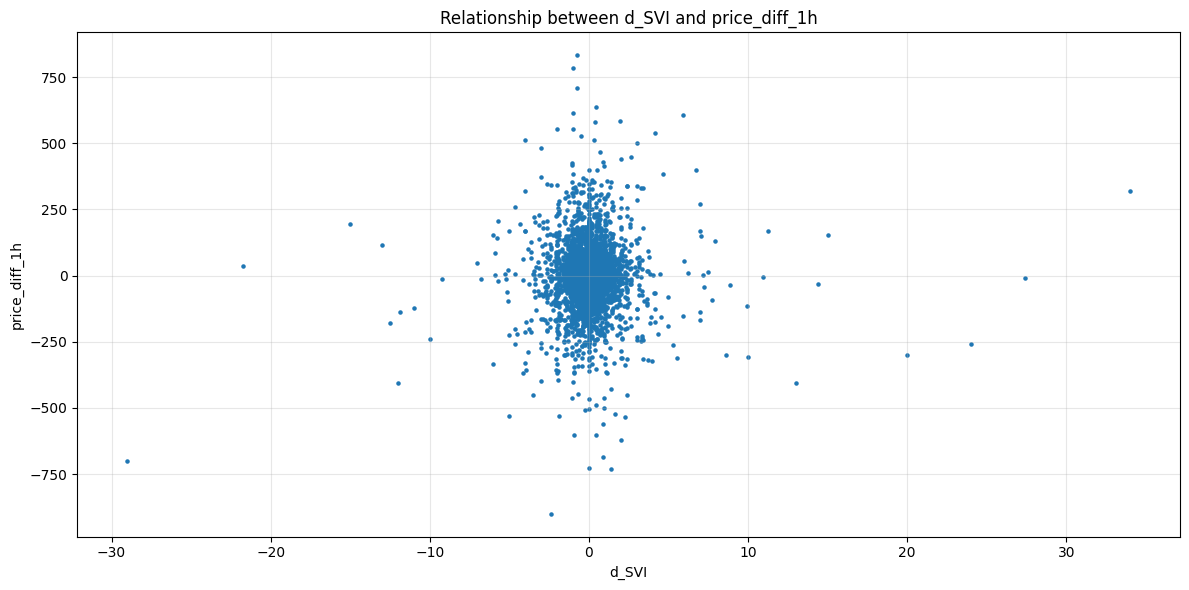

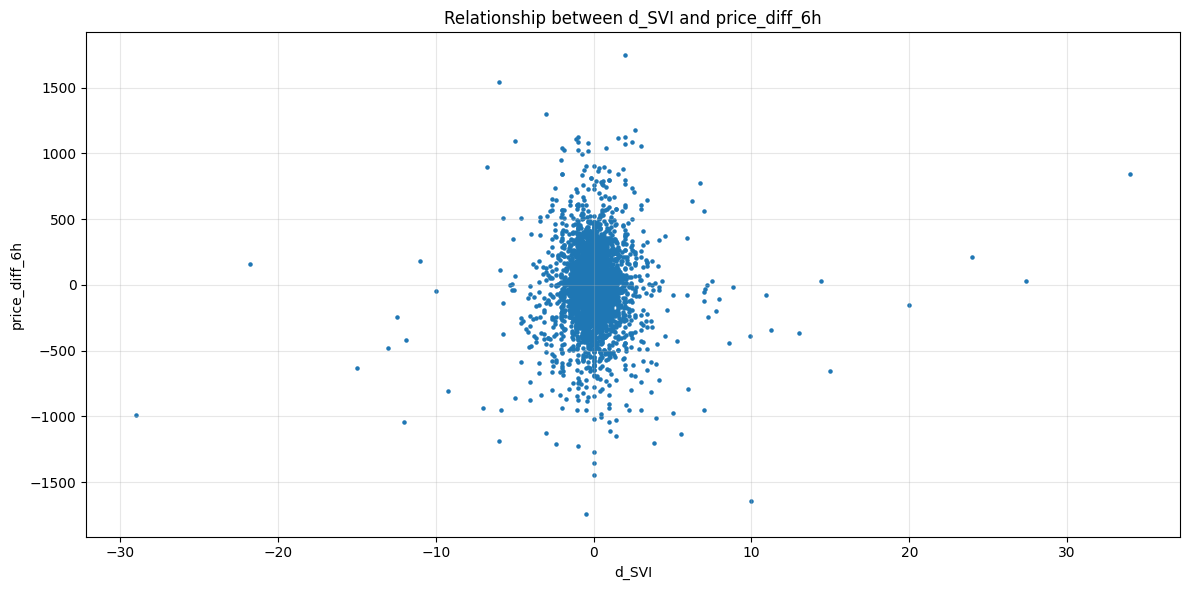

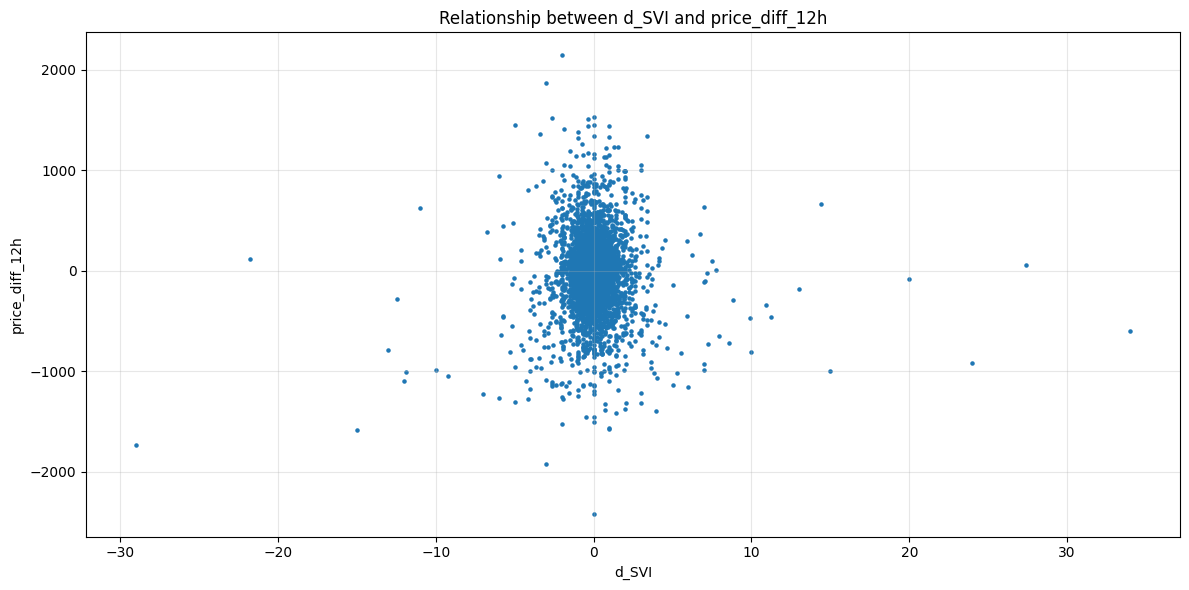

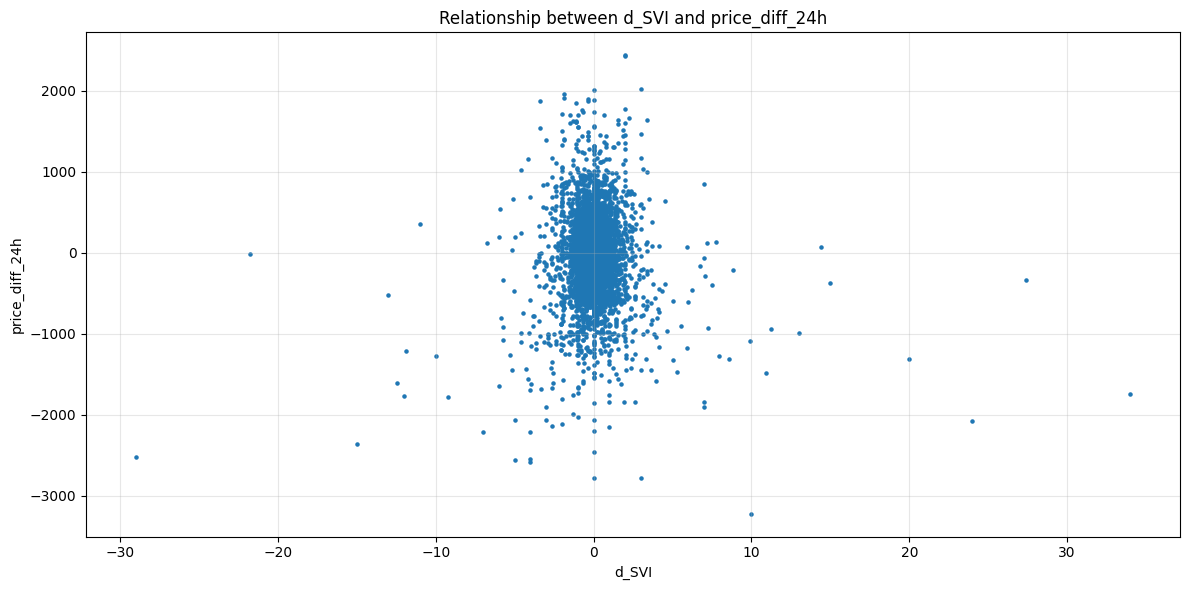

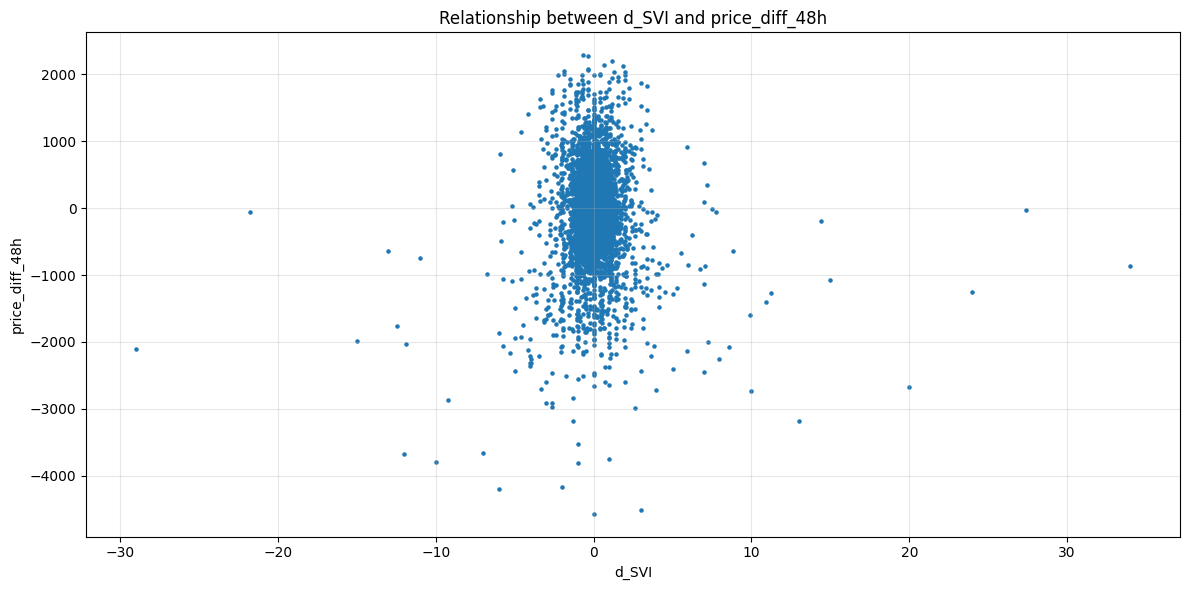

In [47]:
for x in ["SVI", "d_SVI"]:
    for y in ["price_diff_1h", "price_diff_6h",
             "price_diff_12h", "price_diff_24h",
             "price_diff_48h"]:
        plot_scatter(df_svi_mom, x, y, f"Relationship between {x} and {y}")


### Interpretation of the correlation results

- The Search Volume Index (SVI) shows a weak negative correlation with momentums for 1h 6h, 12h, 24h and 48h, which is statistically significant. (reject null hypothesis)
- The difference in Search Volume Index (d_SVI) shows a weak positive correlation with momentums for 1h and 6h, which is statistically significant. (reject null hypothesis)
- The difference in Search Volume Index (d_SVI) shows no correlation with momentums for 12h, 24h and 48h, with p-value > 0.05. (fail to reject null hypothesis)

Again we only choose to model the stronger correlations in this case (SVI, 24h) and (SVI, 48h).

#### OLS model for 24h momentum

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     8.961
Date:                Mon, 15 Dec 2025   Prob (F-statistic):            0.00277
Time:                        02:52:45   Log-Likelihood:                -44295.
No. Observations:                5866   AIC:                         8.859e+04
Df Residuals:                    5864   BIC:                         8.861e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.8065     35.995      2.912      0.0

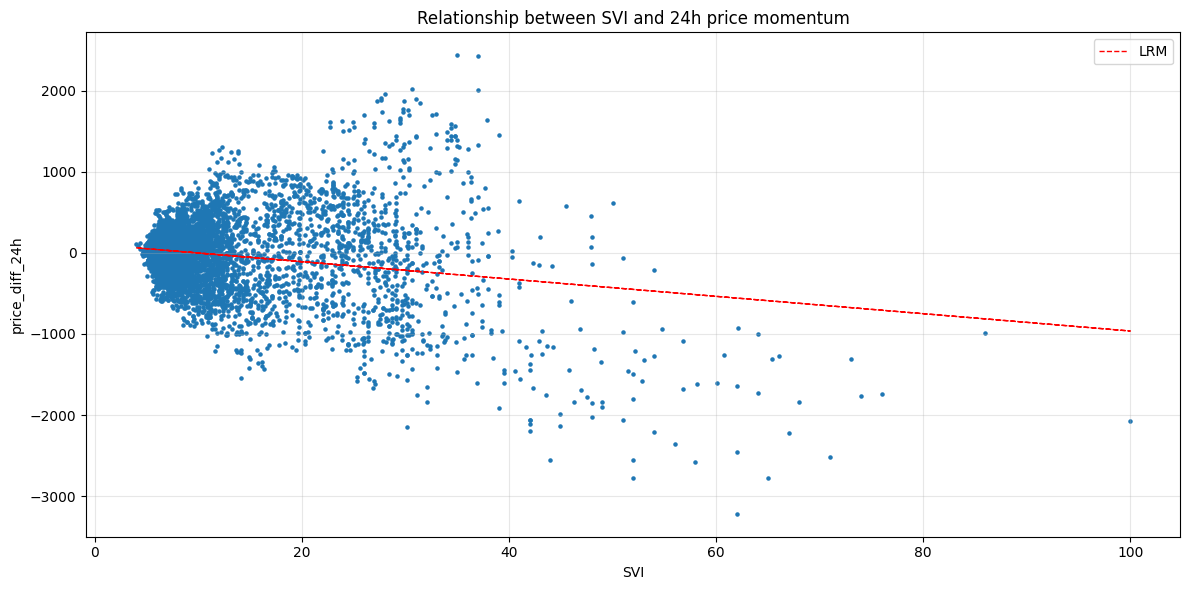

In [48]:
df_sm_24 = df_svi_mom.select(["SVI", "price_diff_24h"]).drop_nulls()
c_mom24, b_mom24 = lrm(df_sm_24, "SVI", "price_diff_24h")
plot_scatter_lrm(df_sm_24, "SVI", "price_diff_24h", "Relationship between SVI and 24h price momentum",
                 c_mom24, b_mom24)

#### OLS model for 48h momentum

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     16.42
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           5.14e-05
Time:                        02:52:46   Log-Likelihood:                -45934.
No. Observations:                5842   AIC:                         9.187e+04
Df Residuals:                    5840   BIC:                         9.189e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        194.4910     50.282      3.868      0.0

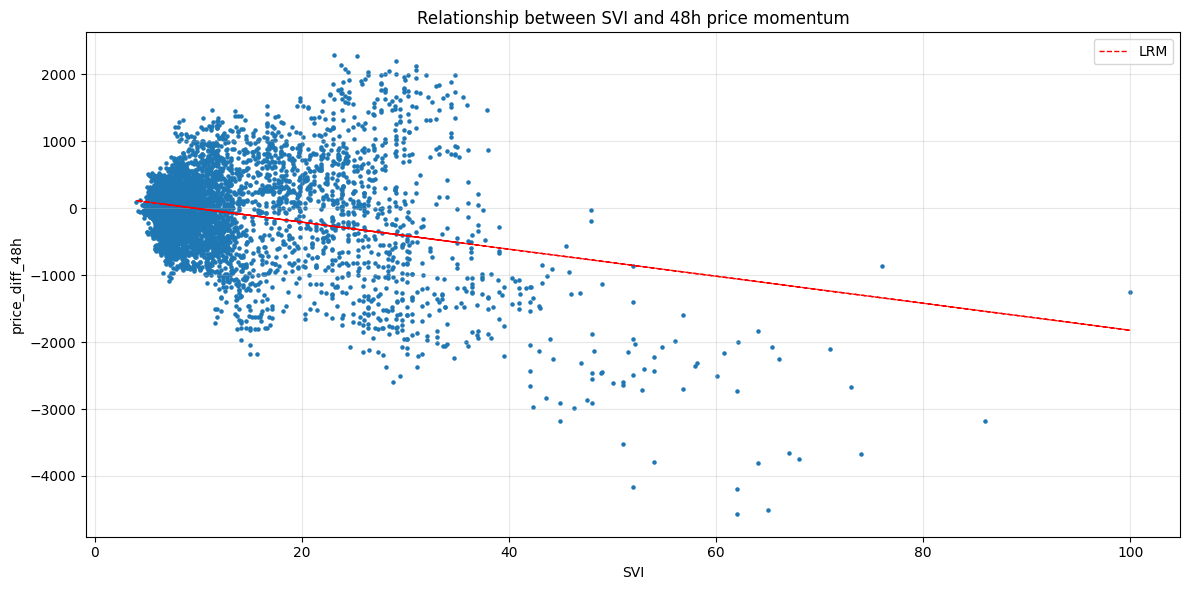

In [49]:
df_sm_48 = df_svi_mom.select(["SVI", "price_diff_48h"]).drop_nulls()
c_mom48, b_mom48 = lrm(df_sm_48, "SVI", "price_diff_48h")
plot_scatter_lrm(df_sm_48, "SVI", "price_diff_48h", "Relationship between SVI and 48h price momentum",
                 c_mom48, b_mom48)

### Validating the LRM for SVI x 24h momentum


In [50]:
# predicted volatility for part 4
df_pred_vol_4 = (df_search_4.with_columns(
    pred_vol = c_mom24 + b_mom24 * pl.col("SVI"))
    .select(["timestamp", "pred_vol"]))


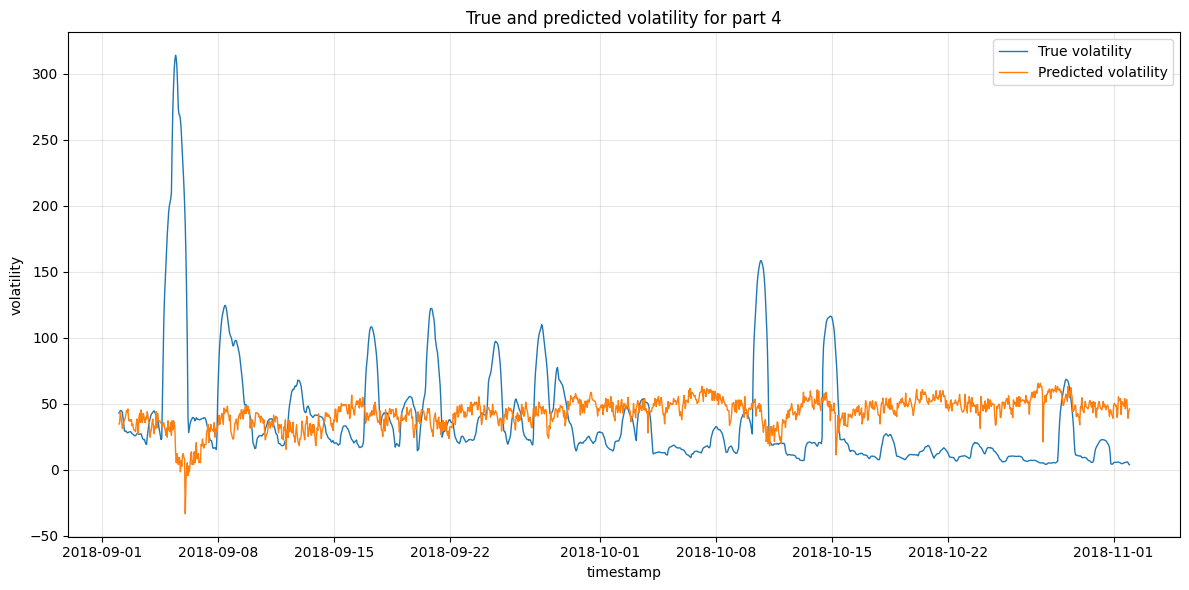

In [51]:
plot_data_2(df_vol_4, "timestamp", "volatility", "True volatility",
            df_pred_vol_4, "timestamp", "pred_vol", "Predicted volatility",
            "True and predicted volatility for part 4")

#### Hypothesis testing
We repeat the previous hypothesis test for the new model.

In [52]:
df_vol_4_loss = df_vol_4.join(
    df_pred_vol_4,
    on="timestamp",
    how="inner")

df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "pred_vol", "loss_model")
df_vol_4_loss = random_walk(df_vol_4_loss, "random_walk", start, step)
df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "random_walk", "loss_bench")

# computind difference (dt) in loss
df_vol_4_loss = df_vol_4_loss.with_columns(
    d = pl.col("loss_model") - pl.col("loss_bench")
)


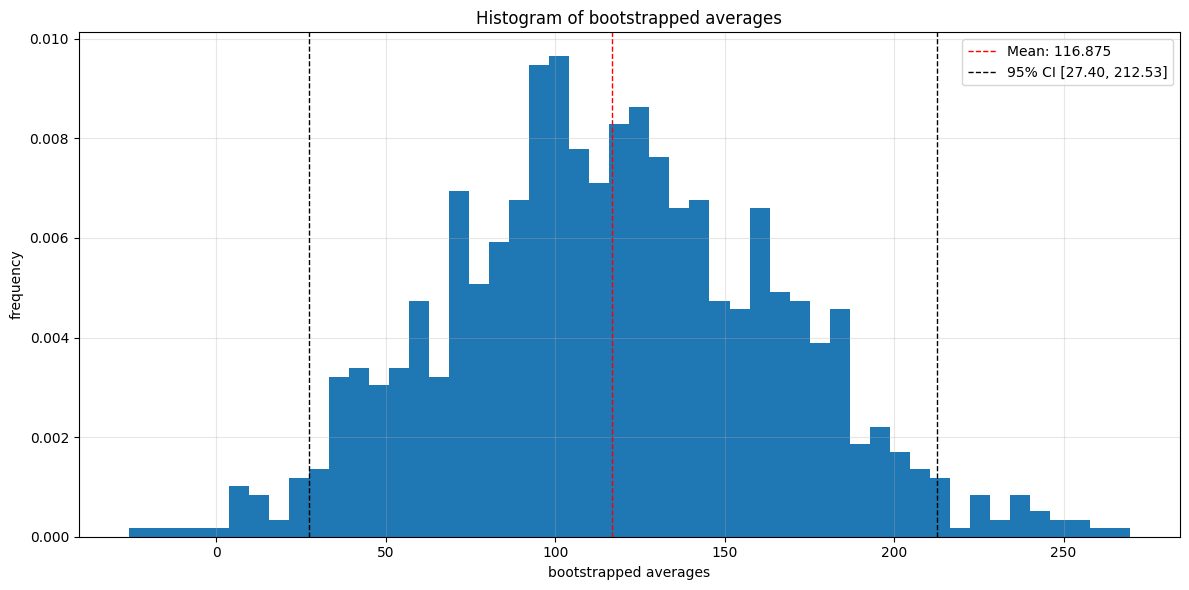

In [53]:
boot_means = bootstrap_means(np.array(df_vol_4_loss["d"]), 10**3)
plot_hist(boot_means, "bootstrapped averages", "Histogram of bootstrapped averages", 50)


The 95% confidence interval for the mean loss differential $L^{model}_t - L^{bench}_t$ lies above 0, indicating that the average is greater than 0. Therefore, we fail to reject the null hypothesis of no predictive power.

### Validating the LRM for SVI x 48h momentum


In [54]:
# predicted volatility for part 4
df_pred_vol_4 = (df_search_4.with_columns(
    pred_vol = c_mom48 + b_mom48 * pl.col("SVI"))
    .select(["timestamp", "pred_vol"]))

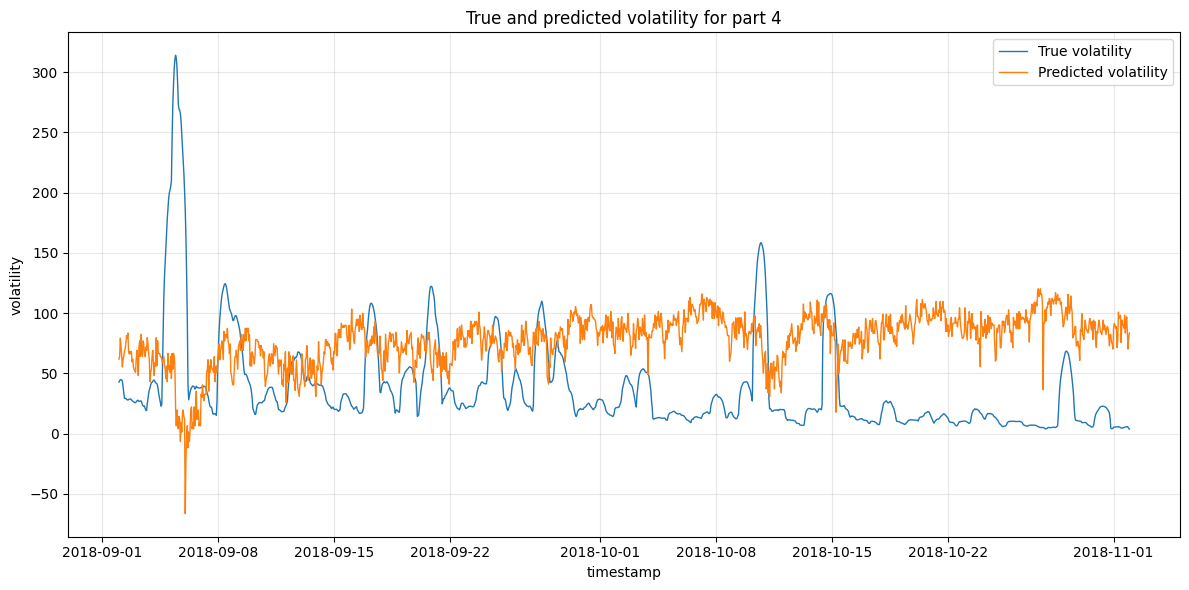

In [55]:
plot_data_2(df_vol_4, "timestamp", "volatility", "True volatility",
            df_pred_vol_4, "timestamp", "pred_vol", "Predicted volatility",
            "True and predicted volatility for part 4")

#### Hypothesis testing

In [56]:
df_vol_4_loss = df_vol_4.join(
    df_pred_vol_4,
    on="timestamp",
    how="inner")

df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "pred_vol", "loss_model")
df_vol_4_loss = random_walk(df_vol_4_loss, "random_walk", start, step)
df_vol_4_loss = loss_function(df_vol_4_loss, "volatility", "random_walk", "loss_bench")

# computind difference (dt) in loss
df_vol_4_loss = df_vol_4_loss.with_columns(
    d = pl.col("loss_model") - pl.col("loss_bench")
)


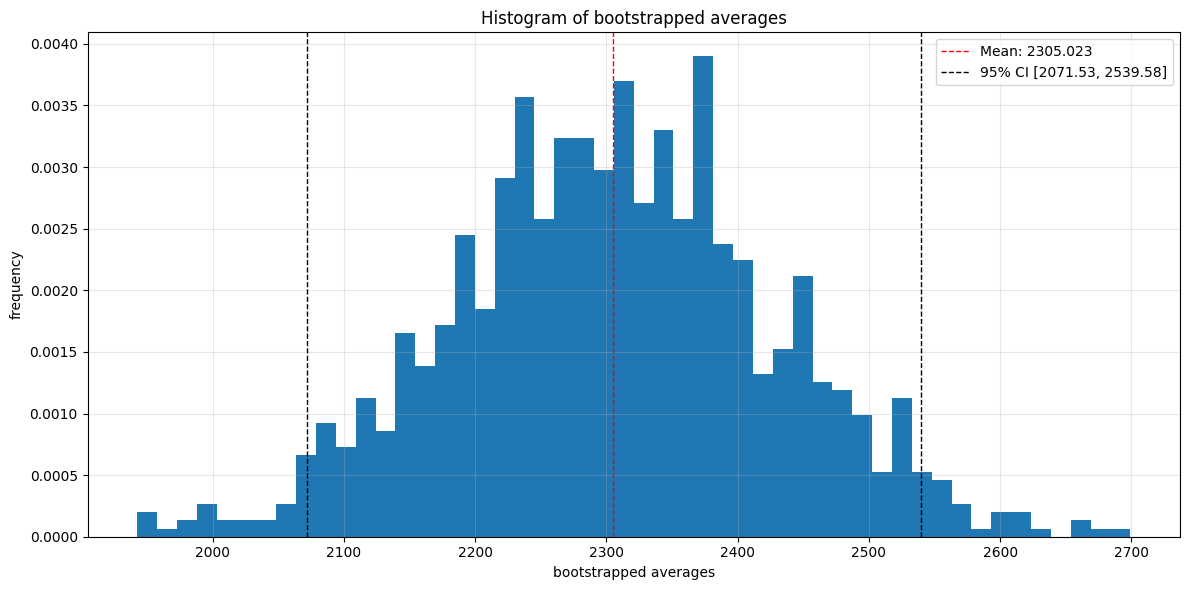

In [57]:
boot_means = bootstrap_means(np.array(df_vol_4_loss["d"]), 10**3)
plot_hist(boot_means, "bootstrapped averages", "Histogram of bootstrapped averages", 50)


The 95% confidence interval for the mean loss differential $L^{model}_t - L^{bench}_t$ lies above 0, indicating that the average is greater than 0. Therefore, we fail to reject the null hypothesis of no predictive power.

## Conclusion
we examined the correlation between Google search results and Bitcoin volatility and momentum. For correlations that were equal to or greater than 0.2, we estimated a regression model and subsequently validated its performance. The results indicate that, despite the correlations, the regression models consistently performed worse than the benchmark, represented by a random walk. This suggests that, in the cases tested, Google search activity provides no predictive power for Bitcoin volatility or momentum.